# 01. Demandas dos revisores — análises sobre a base v7

## 01. Introdução

Este notebook lê a base analítica da revisão sistemática (JHPN, revisão maior) e produz os números, tabelas e figuras exigidos pelas demandas quantitativas dos pareceres (Editor, Revisores 1, 2 e 3). Insumo: `methods/extracao_artigo1_v7.xlsx`, aba `Per Combination` (241 linhas estudo×desfecho×algoritmo, 38 estudos, campos CHARMS 1–10, PROBAST+AI e "3 Most Important Features"). O manuscrito atual usa a base antiga (43 estudos, 47 combinações); todos os números precisam ser recalculados sobre a base de 38 estudos.

Produtos, gravados em `jhpn_revisions/analysis/resultados/`:

1. **Unidades de análise:** `unidades_analise.csv` e `auditoria_desfechos_R2_5.csv` (desfechos extraídos fora do escopo declarado).
2. **Corpus:** `corpus_descritivo.csv` e figura ano×desfecho (nova Figure 2A).
3. **Algoritmos:** `algoritmos.csv` (famílias, Random Forest, deep learning).
4. **Desempenho:** `table2_nova.csv`, `desempenho_estratificado.csv` e boxplot de AUC por desfecho.
5. **Desbalanceamento:** `desbalanceamento.csv` e `heterogeneidade.csv` (fundamenta a ausência de meta-análise).
6. **Finalidade do modelo:** `classificacao_finalidade_TEMPLATE.csv` (caso a caso, para conferência da IVS).
7. **Leakage:** `leakage_recontado.csv` e figura de preditores mais importantes (nova Figure 4).
8. **PROBAST+AI:** `probast_dominios.csv`.
9. **Síntese:** `numeros_manuscrito.csv` (valor antigo × valor novo, por afirmação do texto).

Regras: a v7 é somente leitura e nunca é gravada. NR nunca vira número (vira NaN e sai do denominador, sempre reportado). O denominador de cada número é explícito: estudo (n=38), combinação estudo×desfecho ou linha estudo×desfecho×algoritmo (n=241). Desfechos elegíveis do artigo: stunting, obesity, overweight, thinness; wasting e underweight foram excluídos por decisão de protocolo (T1.5) e aparecem só na auditoria. O template de conferência nunca é regravado quando já existe com marcações.

## 02. Libraries and Mount

Mount Colab-ou-local e uma célula única que instala e importa todas as bibliotecas.

In [40]:
# -- 02.1 Mount (Colab ou local) --
import os
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/USP/Doutorado/Coorte de pelotas/01_artigos/artigo_1'
    AMBIENTE = 'colab'
except ModuleNotFoundError:
    BASE = '../..'
    AMBIENTE = 'local'
V7 = f'{BASE}/methods/extracao_artigo1_v7.xlsx'
OUT_DIR = f'{BASE}/jhpn_revisions/analysis/resultados'
TEMPLATE = f'{OUT_DIR}/classificacao_finalidade_TEMPLATE.csv'
AUDITORIA = f'{OUT_DIR}/auditoria_v7_por_estudo.csv'
DIVERGENCIAS = f'{OUT_DIR}/auditoria_v7_divergencias.csv'
BASE_DADOS = f'{BASE}/base_dados'
FIGURAS = f'{BASE}/jhpn_revisions/figures'
DATA = '20260826'
os.makedirs(OUT_DIR, exist_ok=True)
print(AMBIENTE, '| BASE =', BASE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
colab | BASE = /content/drive/MyDrive/USP/Doutorado/Coorte de pelotas/01_artigos/artigo_1


In [41]:
# -- 02.2 bibliotecas: instala tudo de uma vez e importa --
%pip install -q openpyxl plotly "kaleido==0.2.1"  # kaleido 0.2.1: embute o Chromium; kaleido>=1 precisa baixar o Chrome e falha no Colab sem rede liberada. sem -U: atualizar matplotlib/pandas quebra o backend_pdf
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
pd.set_option('display.max_rows', 120)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 220)

def grava(tab, nome):
    tab.to_csv(f'{OUT_DIR}/{nome}', sep=';', encoding='utf-8-sig', index=False)
    print(f'gravado: resultados/{nome} ({tab.shape[0]} linhas x {tab.shape[1]} colunas)')

# -- estilo unico das figuras (paleta validada para daltonismo; rotulos em ingles) --
CORES = {'stunting': '#2A6FB0', 'obesity': '#C2453A',
         'overweight': '#E08A2E', 'overweight/obesity (combinado)': '#7B5EA7'}
ROTULO_EN = {'stunting': 'Stunting', 'obesity': 'Obesity',
             'overweight': 'Overweight', 'overweight/obesity (combinado)': 'Overweight/obesity'}
TINTA, TINTA2, GRADE_COR = '#222222', '#555555', '#DDDDDD'
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
    'font.family': 'DejaVu Sans', 'font.size': 9,
    'axes.titlesize': 10, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.labelsize': 9, 'axes.labelcolor': TINTA, 'axes.edgecolor': TINTA2,
    'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.color': TINTA2, 'ytick.color': TINTA2, 'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5,
    'legend.frameon': False, 'legend.fontsize': 8.5,
    'grid.color': GRADE_COR, 'grid.linewidth': 0.7, 'text.color': TINTA,
})


# rotulo direto no fim da barra, em vez de um numero em cada segmento empilhado
def rotula_barras(ax, retangulos, valores, dx=0, dy=0, cor=TINTA, tam=8, horizontal=False):
    for r, v in zip(retangulos, valores):
        if not v:
            continue
        if horizontal:
            ax.text(r.get_width() + dx, r.get_y() + r.get_height() / 2, f'{v:g}',
                    va='center', ha='left', fontsize=tam, color=cor)
        else:
            ax.text(r.get_x() + r.get_width() / 2, r.get_height() + dy, f'{v:g}',
                    ha='center', va='bottom', fontsize=tam, color=cor)


def fig_salva(fig, nome):
    fig.savefig(f'{OUT_DIR}/{nome}_{DATA}.png', dpi=200, bbox_inches='tight')
    try:
        fig.savefig(f'{OUT_DIR}/{nome}_{DATA}.pdf', bbox_inches='tight')
        print(f'figura: resultados/{nome}_{DATA}.png/.pdf')
    except Exception as e:  # backend_pdf quebra se a matplotlib foi trocada na sessao
        print(f'figura: resultados/{nome}_{DATA}.png (PDF nao gerado: {type(e).__name__})')

## 03. Abrir a base

A linha 1 da planilha é a faixa de grupos CHARMS; o cabeçalho real é a linha 2 (`header=1`). As colunas padronizadas viram numéricas (NR passa a NaN). Três visões: `df` (241 linhas estudo×desfecho×algoritmo), `df_comb` (uma linha por combinação estudo×desfecho, escolhida pela regra do melhor modelo) e `df_est` (38 estudos).

In [42]:
# -- 03.1 leitura e tipos --
df = pd.read_excel(V7, sheet_name='Per Combination', header=1)
# AA_10 (Kar, 2021) modelou apenas um desfecho composto de desnutricao, sem dimensao
# antropometrica isolavel. E inelegivel, e sai de todas as contagens.
EXCLUIDOS = ['AA_10']
df = df[~df['ID'].isin(EXCLUIDOS)].copy()
METRICAS = ['AUC', 'Accuracy', 'Precision', 'Recall (Sensitivity)', 'Specificity', 'F1-Score']
NUMERICAS = METRICAS + ['Sex (%F)', 'N (sample)', 'N (analysis)', 'N Events', 'EPV (calculated)', 'Events Denominator']
for c in NUMERICAS:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')
assert df.shape[0] == 237, f'esperava 237 linhas, veio {df.shape[0]}'
n_estudos = df['ID'].nunique()
assert n_estudos == 37, f'esperava 37 estudos, veio {n_estudos}'
fora = pd.concat([df[m][(df[m] < 0) | (df[m] > 1)] for m in METRICAS])
assert fora.empty, 'metrica padronizada fora de [0,1]'
print(f'v7: {df.shape[0]} linhas x {df.shape[1]} colunas | {df["ID"].nunique()} estudos | metricas em [0,1] ok')

v7: 237 linhas x 74 colunas | 37 estudos | metricas em [0,1] ok


In [43]:
# -- 03.2 familia de desfecho e prevalencia derivada --
def familia_desfecho(s):
    t = str(s).lower()
    if 'overweight/obesity' in t:
        return 'overweight/obesity (combinado)'
    if 'obes' in t:
        return 'obesity'
    if 'overweight' in t:
        return 'overweight'
    if 'stunt' in t or 'height-for-age' in t:
        return 'stunting'
    if 'wasting' in t:
        return 'wasting'
    if 'underweight' in t:
        return 'underweight'
    if 'thin' in t:
        return 'thinness'
    if 'malnutrition' in t:
        return 'malnutrition (composto)'
    return 'outro'

df['familia'] = df['Outcome'].map(familia_desfecho)
ELEGIVEIS = ['stunting', 'obesity', 'overweight', 'overweight/obesity (combinado)']  # thinness saiu do escopo (26/08); o rotulo combinado e sobrepeso/obesidade e entra
df['elegivel'] = df['familia'].isin(ELEGIVEIS)
denom = df['Events Denominator'].fillna(df['N (analysis)']).fillna(df['N (sample)'])
df['prevalencia'] = df['N Events'] / denom
assert (df.loc[df['prevalencia'].notna(), 'prevalencia'].between(0, 1)).all(), 'prevalencia fora de [0,1]'
print(df['familia'].value_counts().to_string())
print(f"linhas elegiveis: {int(df['elegivel'].sum())}/241 | prevalencia calculavel em {int(df['prevalencia'].notna().sum())} linhas")

familia
stunting                          120
wasting                            37
underweight                        34
obesity                            30
overweight                         14
overweight/obesity (combinado)      2
linhas elegiveis: 166/241 | prevalencia calculavel em 168 linhas


In [44]:
# -- 03.3 visoes: combinacao (melhor modelo) e estudo --
linhas, via_yes = [], 0
for (sid, fam), g in df.groupby(['ID', 'familia']):
    g = g.copy()
    g['_yes'] = g['Best Model?'].astype(str).str.strip().str.lower().eq('yes')
    g = g.sort_values(['_yes', 'AUC', 'Accuracy', 'F1-Score'],
                      ascending=[False, False, False, False], na_position='last')
    via_yes += int(g['_yes'].iloc[0])
    linhas.append(g.iloc[0].drop('_yes'))
df_comb = pd.DataFrame(linhas).reset_index(drop=True)
df_comb_eleg = df_comb[df_comb['elegivel']].copy()
df_est = df.drop_duplicates('ID').copy()
print(f'combinacoes estudo x desfecho: {len(df_comb)} (elegiveis: {len(df_comb_eleg)})')
print(f'combinacoes resolvidas pela marca Best Model = Yes: {via_yes}; por maior AUC/Accuracy: {len(df_comb) - via_yes}')
print(f'estudos: {len(df_est)}')

combinacoes estudo x desfecho: 53 (elegiveis: 39)
combinacoes resolvidas pela marca Best Model = Yes: 52; por maior AUC/Accuracy: 1
estudos: 37


## 04. Unidades de análise e N canônico

O manuscrito diz "43 studies representing 47 study-outcome combinations". A base atual tem 38 estudos. Aqui ficam os N novos por desfecho e a auditoria da demanda R2.5: o Revisor 2 apontou inconsistência sobre wasting e underweight (objetivos incluem, seções posteriores excluem). A extração CHARMS registrou TODOS os desfechos reportados pelos artigos; os fora do escopo declarado vão para `auditoria_desfechos_R2_5.csv`, para a IVS decidir a redação do texto (a exclusão está declarada nos comentários T1.5).

In [45]:
# -- 04.1 combinacoes por desfecho: novo vs manuscrito --
ANTIGO = {'stunting': 32, 'obesity': 9, 'overweight': 5, 'thinness': 1}  # Table 1 atual (47 combinacoes)
novo = df_comb['familia'].value_counts()
uni = pd.DataFrame({'desfecho': novo.index,
                    'combinacoes_v7': novo.values,
                    'combinacoes_manuscrito_47': [ANTIGO.get(f, 0) for f in novo.index],
                    'elegivel_artigo': [f in ELEGIVEIS for f in novo.index]})
uni['estudos_v7'] = [df_comb.loc[df_comb['familia'] == f, 'ID'].nunique() for f in uni['desfecho']]
uni = uni.sort_values('combinacoes_v7', ascending=False).reset_index(drop=True)
print(uni.to_string(index=False))
n_comb_eleg = len(df_comb_eleg)
n_est_eleg = df_comb_eleg['ID'].nunique()
print(f'\nN canonico proposto: {n_est_eleg} estudos com desfecho elegivel, {n_comb_eleg} combinacoes elegiveis')
print(f'(manuscrito atual: 43 estudos, 47 combinacoes; PROBAST ja usa 38)')
grava(uni, 'unidades_analise.csv')

                      desfecho  combinacoes_v7  combinacoes_manuscrito_47  elegivel_artigo  estudos_v7
                      stunting              30                         32             True          30
                   underweight               7                          0            False           7
                       wasting               7                          0            False           7
                       obesity               6                          9             True           6
                    overweight               2                          5             True           2
overweight/obesity (combinado)               1                          0             True           1

N canonico proposto: 37 estudos com desfecho elegivel, 39 combinacoes elegiveis
(manuscrito atual: 43 estudos, 47 combinacoes; PROBAST ja usa 38)
gravado: resultados/unidades_analise.csv (6 linhas x 5 colunas)


In [46]:
# -- 04.2 auditoria R2.5: desfechos extraidos fora do escopo declarado --
aud = df_comb[~df_comb['elegivel']][['ID', 'First Author', 'Year', 'familia', 'Outcome']].copy()
aud = aud.sort_values(['familia', 'ID']).reset_index(drop=True)
aud['acao_sugerida'] = 'fora do escopo declarado (T1.5): nao entra nos numeros do artigo; citar exclusao em Methods'
print(aud[['ID', 'First Author', 'familia']].to_string(index=False))
n_est_fora = aud['ID'].nunique()
so_fora = set(df_comb['ID']) - set(df_comb_eleg['ID'])
print(f'\n{len(aud)} combinacoes fora do escopo, em {n_est_fora} estudos')
print(f'estudos SEM nenhum desfecho elegivel (entram no artigo?): {sorted(so_fora) if so_fora else "nenhum"}')
print('atencao: thinness nao aparece na v7; o unico estudo de thinness da base antiga nao esta entre os 38')
grava(aud, 'auditoria_desfechos_R2_5.csv')

   ID           First Author     familia
AA_01              Berrouyne underweight
AA_02                   Anku underweight
AA_05 Rahman, S. M. Jubaidur underweight
AA_07     Chen (Kening Chen) underweight
AA_45                Tamanna underweight
AA_56                 Saleem underweight
AA_59     Islam, Md. Merajul underweight
AA_01              Berrouyne     wasting
AA_02                   Anku     wasting
AA_05 Rahman, S. M. Jubaidur     wasting
AA_45                Tamanna     wasting
AA_55              Mgomezulu     wasting
AA_56                 Saleem     wasting
AA_59     Islam, Md. Merajul     wasting

14 combinacoes fora do escopo, em 8 estudos
estudos SEM nenhum desfecho elegivel (entram no artigo?): nenhum
atencao: thinness nao aparece na v7; o unico estudo de thinness da base antiga nao esta entre os 38
gravado: resultados/auditoria_desfechos_R2_5.csv (14 linhas x 6 colunas)


## 05. Corpus

Descritivos sobre os estudos e as combinações elegíveis: países (grafias normalizadas; o texto diz "15 countries" com EUA em 3 grafias), a concentração na Indonésia (R1.3 e R2.2 usam denominadores diferentes: estudo e combinação), ano de publicação, fonte de dados e tamanho amostral. Figura ano×desfecho substitui a Figure 2A.

In [47]:
# -- 05.1 paises normalizados e Indonesia --
def pais_norm(s):
    t = str(s).strip()
    if t.upper().startswith('USA') or t == 'United States':
        return 'USA'
    if t.lower().startswith('asia'):
        return 'Asia (dataset multinacional)'
    return t

df['pais'] = df['Country/Region'].map(pais_norm)
df_comb_eleg['pais'] = df_comb_eleg['Country/Region'].map(pais_norm)
df_est['pais'] = df_est['Country/Region'].map(pais_norm)
paises = df_est['pais'].value_counts()
print(paises.to_string())
n_paises = df_est.loc[df_est['pais'] != 'Asia (dataset multinacional)', 'pais'].nunique()
print(f'\npaises distintos (sem contar o dataset multinacional): {n_paises} (manuscrito diz 15)')
ind_e = int((df_est['pais'] == 'Indonesia').sum())
ind_c = int((df_comb_eleg['pais'] == 'Indonesia').sum())
print(f'Indonesia: {ind_e}/{len(df_est)} estudos ({100*ind_e/len(df_est):.0f}%) | '
      f'{ind_c}/{n_comb_eleg} combinacoes elegiveis ({100*ind_c/n_comb_eleg:.0f}%) | manuscrito: 23/47 (49%)')

pais
Indonesia           17
USA                  4
Bangladesh           3
Morocco              2
Rwanda               2
Ghana                1
China                1
Brazil               1
Malawi               1
Mexico               1
Pakistan             1
Ethiopia             1
Papua New Guinea     1
Zambia               1

paises distintos (sem contar o dataset multinacional): 14 (manuscrito diz 15)
Indonesia: 17/37 estudos (46%) | 17/39 combinacoes elegiveis (44%) | manuscrito: 23/47 (49%)


In [48]:
# -- 05.2 ano, fonte de dados e amostra --
def fonte(s):
    t = str(s).lower()
    if 'dhs' in t or 'mics' in t or 'household survey' in t or 'health survey' in t or 'ensanut' in t or 'lsms' in t:
        return 'inquerito populacional (DHS/MICS/nacional)'
    if 'ehr' in t or 'electronic health record' in t:
        return 'registro eletronico de saude (EHR)'
    if 'kaggle' in t or 'open dataset' in t or 'open-source dataset' in t:
        return 'dataset aberto (Kaggle/nao especificado)'
    if 'school' in t:
        return 'inquerito escolar'
    if 'panel' in t or 'family life survey' in t:
        return 'painel longitudinal domiciliar'
    if 'health center' in t or 'health service' in t or 'growth monitoring' in t or 'posyandu' in t or 'puskesmas' in t or 'health office' in t or 'checkup' in t or 'nutrition survey' in t:
        return 'servico de saude local (registros de rotina)'
    return 'outra'

df_est['fonte_dados'] = df_est['Source Type'].map(fonte)
print(df_est['fonte_dados'].value_counts().to_string())
anos = df_est['Year'].value_counts().sort_index()
print('\nano de publicacao (estudos):', dict(anos))
pico = anos.idxmax()
print(f'pico: {int(anos.max())}/{len(df_est)} estudos em {pico} ({100*anos.max()/len(df_est):.0f}%) | manuscrito: 26/47 (55%) em 2024')
ns = df_est['N (sample)'].dropna()
print(f'\nN amostral ({len(ns)}/38 estudos com N): {int(ns.min())} a {int(ns.max())}, mediana {int(ns.median())} '
      f'| manuscrito: 114 a 244.053, mediana 6.677')
corpus = df_est[['ID', 'First Author', 'Year', 'pais', 'fonte_dados', 'N (sample)', 'Age (months)', 'Setting']].copy()
grava(corpus.sort_values('ID'), 'corpus_descritivo.csv')

fonte_dados
inquerito populacional (DHS/MICS/nacional)      15
servico de saude local (registros de rotina)    12
dataset aberto (Kaggle/nao especificado)         3
inquerito escolar                                3
registro eletronico de saude (EHR)               3
painel longitudinal domiciliar                   1

ano de publicacao (estudos): {np.int64(2021): np.int64(3), np.int64(2022): np.int64(2), np.int64(2023): np.int64(3), np.int64(2024): np.int64(19), np.int64(2025): np.int64(10)}
pico: 19/37 estudos em 2024 (51%) | manuscrito: 26/47 (55%) em 2024

N amostral (37/38 estudos com N): 114 a 244053, mediana 6801 | manuscrito: 114 a 244.053, mediana 6.677
gravado: resultados/corpus_descritivo.csv (37 linhas x 8 colunas)


figura: resultados/fig2_distribuicao_20260826.png/.pdf


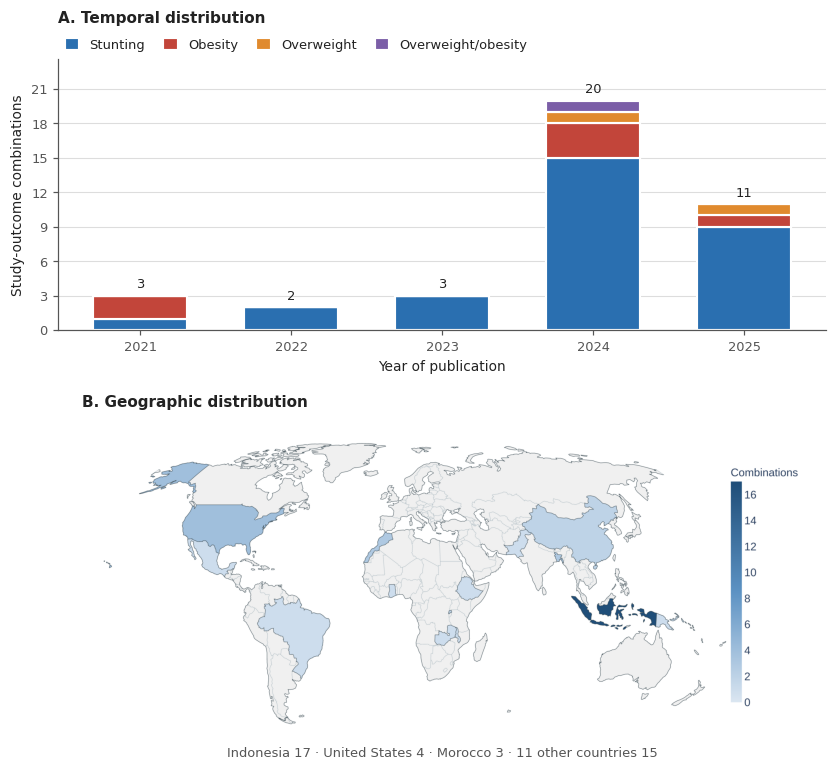

painel B: mapa | paises: 14 | combinacoes: 39


In [49]:
# -- 05.3 Figure 2: (A) ano x desfecho, (B) mapa mundi --
tab_af = df_comb_eleg.pivot_table(index='Year', columns='familia', values='ID', aggfunc='count').fillna(0)
tab_af = tab_af[[c for c in ELEGIVEIS if c in tab_af.columns]]
anos_rot = [str(int(a)) for a in tab_af.index]  # nome proprio: 'anos' e a serie da secao 05.2

fig = plt.figure(figsize=(9, 8.2))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.25], hspace=0.28)
ax = fig.add_subplot(gs[0])
fundo = np.zeros(len(tab_af))
for c in tab_af.columns:
    ax.bar(anos_rot, tab_af[c], bottom=fundo, label=ROTULO_EN[c], color=CORES[c],
           width=0.62, edgecolor='white', linewidth=1.4)
    fundo += tab_af[c].values
for x, tot in zip(anos_rot, fundo):
    ax.text(x, tot + 0.4, f'{int(tot)}', ha='center', va='bottom', fontsize=8.5, color=TINTA)
ax.set_xlabel('Year of publication')
ax.set_ylabel('Study-outcome combinations')
ax.set_title('A. Temporal distribution', pad=24)
ax.set_ylim(0, fundo.max() * 1.18)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(ncols=4, loc='lower left', bbox_to_anchor=(0, 1.005), handlelength=1.1, handleheight=1.1,
          columnspacing=1.4, borderpad=0)
ax.set_axisbelow(True)
ax.yaxis.grid(True)

# painel B: mapa por pais. Se plotly/kaleido nao estiverem disponiveis, cai para barras ordenadas.
por_pais = (df_comb_eleg[df_comb_eleg['pais'] != 'Asia (dataset multinacional)']
            .groupby('pais')['ID'].count().sort_values(ascending=False))
NOME_MAPA = {'USA': 'United States'}
bx = fig.add_subplot(gs[1])
bx.set_title('B. Geographic distribution', pad=6)
try:
    import plotly.express as px
    mapa = px.choropleth(
        pd.DataFrame({'pais': [NOME_MAPA.get(p, p) for p in por_pais.index], 'n': por_pais.values}),
        locations='pais', locationmode='country names', color='n',
        color_continuous_scale=[[0, '#DCE7F2'], [0.5, '#5D93C4'], [1, '#1F4E79']],
        range_color=(0, int(por_pais.max())))
    # contorno de pais reforcado (31/08): borda branca de 0.4 nao separava os paises vizinhos
    mapa.update_traces(marker_line_color='#37474F', marker_line_width=0.9)
    mapa.update_geos(showframe=False, projection_type='robinson',
                     showland=True, landcolor='#F0F0F0', showlakes=False,
                     showcountries=True, countrycolor='#90A4AE', countrywidth=0.6,
                     showcoastlines=True, coastlinecolor='#37474F', coastlinewidth=0.9,
                     lataxis_range=[-58, 80], lonaxis_range=[-168, 182])
    mapa.update_layout(margin=dict(l=0, r=0, t=0, b=0), paper_bgcolor='white',
                       coloraxis_colorbar=dict(title='Combinations', thickness=26, len=0.72,
                                               tickfont=dict(size=26), title_font=dict(size=26),
                                               outlinewidth=0, x=0.99))
    mapa.write_image(f'{OUT_DIR}/_mapa_tmp.png', width=1700, height=800, scale=2)
    bx.imshow(plt.imread(f'{OUT_DIR}/_mapa_tmp.png'))
    bx.axis('off')
    os.remove(f'{OUT_DIR}/_mapa_tmp.png')
    resto = por_pais.iloc[3:]
    linha_rank = ' · '.join(f'{NOME_MAPA.get(k, k)} {v}' for k, v in por_pais.head(3).items())
    linha_rank += f' · {len(resto)} other countries {int(resto.sum())}'
    bx.text(0.5, 0.02, linha_rank, transform=bx.transAxes, ha='center', va='top',
            fontsize=8.5, color=TINTA2)
    modo_mapa = 'mapa'
except Exception as e:
    ordem = por_pais.sort_values()
    barras = bx.barh(ordem.index, ordem.values, color='#5D93C4', height=0.7)
    rotula_barras(bx, barras, ordem.values, dx=0.15, horizontal=True)
    bx.set_xlabel('Study-outcome combinations')
    bx.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    modo_mapa = f'barras ({type(e).__name__}: {e})'
    print(f'AVISO: painel B caiu no fallback de barras em vez do mapa. Motivo: {type(e).__name__}: {e}')
fig_salva(fig, 'fig2_distribuicao')
plt.show()
print(f'painel B: {modo_mapa} | paises: {len(por_pais)} | combinacoes: {int(por_pais.sum())}')

## 06. Algoritmos

Demanda R1.1: por que ensembles simples dominam e deep learning aparece pouco. Frequência por família de algoritmo em três denominadores (linha, combinação elegível pelo melhor modelo, estudo), mais tuning e tratamento de desbalanceamento reportados.

In [50]:
# -- 06.1 familia de algoritmo --
def familia_algoritmo(s):
    t = str(s).lower()
    if 'stack' in t or 'voting' in t:
        return 'ensemble heterogeneo (stacking/voting)'
    if 'lstm' in t or 'deep learning' in t or 'dnn' in t or 'deep neural' in t:
        return 'deep learning'
    if 'boost' in t or 'xgb' in t or 'lgb' in t or 'catboost' in t:
        return 'boosting'
    if 'random forest' in t or 'bagging' in t:
        return 'random forest/bagging'
    if 'neural' in t or 'mlp' in t:
        return 'rede neural rasa'
    if 'logistic' in t or 'lasso' in t or 'ridge' in t or 'elastic' in t or 'lda' in t or 'mars' in t:
        return 'regressao/linear'
    if 'svm' in t or 'support vector' in t:
        return 'SVM'
    if 'nearest neighbor' in t or 'knn' in t or 'k-nn' in t:
        return 'KNN'
    if 'naive bayes' in t or 'gnb' in t or 'bnb' in t:
        return 'naive bayes'
    if 'tree' in t or 'cart' in t or 'ctree' in t:
        return 'arvore de decisao'
    if 'gaussian process' in t:
        return 'gaussian process'
    return 'outro'

df['alg_familia'] = df['Algorithm'].map(familia_algoritmo)
df_comb_eleg['alg_familia'] = df_comb_eleg['Algorithm'].map(familia_algoritmo)
sobra = df.loc[df['alg_familia'] == 'outro', 'Algorithm'].unique()
assert len(sobra) == 0, f'algoritmos sem familia: {sobra}'
alg = pd.DataFrame({'linhas_241': df['alg_familia'].value_counts(),
                    'combinacoes_melhor_modelo': df_comb_eleg['alg_familia'].value_counts(),
                    'estudos_que_usam': df.groupby('alg_familia')['ID'].nunique()}).fillna(0).astype(int)
alg = alg.sort_values('linhas_241', ascending=False)
print(alg.to_string())
eh_rf = df['Algorithm'].str.lower().str.contains('random forest')
rf = int(eh_rf.sum())
rf_est = df.loc[eh_rf, 'ID'].nunique()
rf_melhor = int(df_comb_eleg['Algorithm'].str.lower().str.contains('random forest').sum())
dl_est = df.loc[df['alg_familia'] == 'deep learning', 'ID'].unique()
print(f'\nRandom Forest: {rf}/241 linhas ({100*rf/241:.0f}%); usado em {rf_est}/38 estudos '
      f'({100*rf_est/38:.0f}%); melhor modelo em {rf_melhor}/{n_comb_eleg} combinacoes elegiveis '
      f'({100*rf_melhor/n_comb_eleg:.0f}%) | manuscrito: 16/47 (34%), sem denominador declarado')
print(f'deep learning: {len(dl_est)} estudos ({list(dl_est)}) | manuscrito: two studies')
grava(alg.reset_index().rename(columns={'index': 'familia_algoritmo'}), 'algoritmos.csv')

                                        linhas_241  combinacoes_melhor_modelo  estudos_que_usam
alg_familia                                                                                    
boosting                                        50                          9                20
random forest/bagging                           48                         14                26
regressao/linear                                43                          3                18
SVM                                             25                          3                12
KNN                                             18                          2                12
arvore de decisao                               15                          1                 9
rede neural rasa                                15                          3                10
naive bayes                                     12                          0                 8
deep learning                           

In [51]:
# -- 06.2 tuning e desbalanceamento reportados (por estudo) --
def reportado(s):
    t = str(s).strip().lower()
    return not (t in ('nr', 'nan', '') or t.startswith('nr ') or t.startswith('none') or t.startswith('no ') or t.startswith('not '))

tun = df_est['Hyperparameter Tuning'].map(reportado)
imb = df_est['Imbalance Handling'].map(reportado)
smote = df_est['Imbalance Handling'].astype(str).str.lower().str.contains('smote')
print(f'tuning de hiperparametros reportado: {int(tun.sum())}/38 estudos ({100*tun.mean():.0f}%)')
print(f'tratamento de desbalanceamento reportado: {int(imb.sum())}/38 ({100*imb.mean():.0f}%), dos quais SMOTE: {int(smote.sum())}')

tuning de hiperparametros reportado: 18/38 estudos (49%)
tratamento de desbalanceamento reportado: 21/38 (57%), dos quais SMOTE: 10


## 07. Desempenho por desfecho, estratificado

Demanda R2.8 (e comentário 22 do Doc): comparar AUC mediana entre desfechos pode ser enganoso porque populações, prevalências, amostras e validações diferem. A Table 2 nova traz N, mediana e IQR por desfecho; os estratos por tipo de validação mostram o quanto o desempenho depende do desenho, e não só do desfecho. Unidade: combinação elegível, melhor modelo.

In [52]:
# -- 07.1 Table 2 nova --
def r2(x):
    # um unico caminho de arredondamento no notebook inteiro: round() e formatacao divergem em
    # valores exatamente na metade (a mediana de AUC de obesity e 0.785 -> 0.78 vs 0.79)
    return float(f'{x:.2f}') if pd.notna(x) else np.nan

def resumo_metrica(g, col):
    v = g[col].dropna()
    if len(v) == 0:
        return pd.Series({f'{col}_N': 0, f'{col}_mediana': np.nan, f'{col}_IQR': ''})
    return pd.Series({f'{col}_N': len(v), f'{col}_mediana': r2(v.median()),
                      f'{col}_IQR': f'{v.quantile(.25):.2f}-{v.quantile(.75):.2f}'})

blocos = []
for fam, g in df_comb_eleg.groupby('familia'):
    linha = pd.concat([resumo_metrica(g, m) for m in ['AUC', 'Accuracy', 'F1-Score']])
    linha['desfecho'] = fam
    linha['combinacoes'] = len(g)
    blocos.append(linha)
t2 = pd.DataFrame(blocos).set_index('desfecho').sort_values('combinacoes', ascending=False)
print(t2.to_string())
auc_rep = int(df_comb_eleg['AUC'].notna().sum())
print(f'\nAUC reportada: {auc_rep}/{n_comb_eleg} combinacoes ({100*auc_rep/n_comb_eleg:.0f}%) | manuscrito: 20/47 (43%)')
print('referencia manuscrito: stunting AUC 0.72 (0.63-0.87) n=8; obesity 0.81 (0.78-0.83) n=7; '
      'overweight 0.66 (0.62-0.73) n=4; accuracy stunting 0.88 (0.84-0.99) n=31')
grava(t2.reset_index(), 'table2_nova.csv')

                                AUC_N  AUC_mediana    AUC_IQR  Accuracy_N  Accuracy_mediana Accuracy_IQR  F1-Score_N  F1-Score_mediana F1-Score_IQR  combinacoes
desfecho                                                                                                                                                        
stunting                           12         0.86  0.75-1.00          30              0.88    0.80-0.99          23              0.89    0.71-0.98           30
obesity                             5         0.79  0.78-0.81           3              0.87    0.77-0.92           1              0.45    0.45-0.45            6
overweight                          2         0.71  0.67-0.76           1              0.89    0.89-0.89           0               NaN                         2
overweight/obesity (combinado)      1         0.62  0.62-0.62           0               NaN                        0               NaN                         1

AUC reportada: 20/39 combinacoes 

In [53]:
# -- 07.2 estratos por tipo de validacao --
def cat_validacao(s):
    t = str(s).lower()
    if 'external' in t:
        return 'externa'
    if t.startswith('nr') or t in ('nan', ''):
        return 'NR/aparente'
    tem_kf, tem_ho = 'k-fold' in t or 'cv' in t, 'holdout' in t or 'split' in t
    so_tuning = 'tuning' in t or 'hyperparameter' in t or 'training' in t or 'up-sampling' in t
    if tem_kf and tem_ho and not so_tuning:
        return 'mista/indefinida'
    if tem_ho:
        return 'holdout'
    if tem_kf:
        return 'k-fold CV'
    return 'outra'

df_comb_eleg['validacao'] = df_comb_eleg['Validation Type'].map(cat_validacao)
print(df_comb_eleg['validacao'].value_counts().to_string())
ext = df_comb_eleg[df_comb_eleg['validacao'] == 'externa']
print(f'\nvalidacao externa: {ext["ID"].nunique()} estudo(s) ({list(ext["ID"].unique())}) | manuscrito: one study (2%)')
estr = (df_comb_eleg.groupby(['familia', 'validacao'])
        .agg(combinacoes=('ID', 'count'), AUC_mediana=('AUC', 'median'),
             Accuracy_mediana=('Accuracy', 'median'), N_mediano=('N (sample)', 'median'))
        .reset_index())
for c in ['AUC_mediana', 'Accuracy_mediana']:
    estr[c] = estr[c].map(r2)
print()
print(estr.to_string(index=False))
grava(estr, 'desempenho_estratificado.csv')

validacao
holdout             31
k-fold CV            5
mista/indefinida     1
NR/aparente          1
externa              1

validacao externa: 1 estudo(s) (['AA_63']) | manuscrito: one study (2%)

                       familia        validacao  combinacoes  AUC_mediana  Accuracy_mediana  N_mediano
                       obesity          externa            1          NaN               NaN    36191.0
                       obesity          holdout            5         0.79              0.87    18503.0
                    overweight          holdout            2         0.71              0.89    12243.0
overweight/obesity (combinado)        k-fold CV            1         0.62               NaN     6801.0
                      stunting      NR/aparente            1          NaN              0.74      114.0
                      stunting          holdout           24         0.82              0.91     6738.0
                      stunting        k-fold CV            4         0.90       

figura: resultados/figS1_auc_desfecho_20260826.png/.pdf


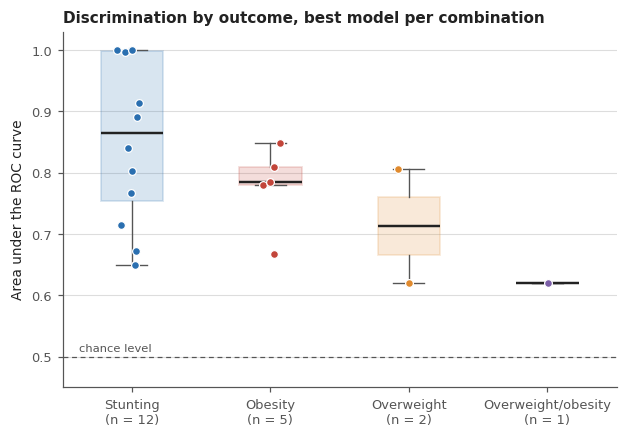

In [54]:
# -- 07.3 Figura S1: AUC por desfecho (pontos + caixa) --
fams = [f for f in ELEGIVEIS if df_comb_eleg.loc[df_comb_eleg['familia'] == f, 'AUC'].notna().any()]
dados = [df_comb_eleg.loc[df_comb_eleg['familia'] == f, 'AUC'].dropna() for f in fams]
fig, ax = plt.subplots(figsize=(6.5, 4.2))
cx = ax.boxplot(dados, widths=0.45, showfliers=False, patch_artist=True,
                medianprops=dict(color=TINTA, linewidth=1.6),
                whiskerprops=dict(color=TINTA2, linewidth=0.9),
                capprops=dict(color=TINTA2, linewidth=0.9))
for caixa_i, f in zip(cx['boxes'], fams):
    caixa_i.set(facecolor=CORES[f], alpha=0.18, edgecolor=CORES[f], linewidth=1.2)
rng = np.random.default_rng(20260826)
for i_f, (f, d) in enumerate(zip(fams, dados), start=1):
    ax.scatter(rng.normal(i_f, 0.045, len(d)), d, s=26, color=CORES[f],
               edgecolor='white', linewidth=0.8, zorder=3)
ax.set_xticks(range(1, len(fams) + 1))
ax.set_xticklabels([f'{ROTULO_EN[f]}\n(n = {len(d)})' for f, d in zip(fams, dados)])
ax.set_ylabel('Area under the ROC curve')
ax.set_title('Discrimination by outcome, best model per combination')
ax.axhline(0.5, color=TINTA2, linewidth=0.8, linestyle=(0, (4, 3)))
ax.text(0.62, 0.505, 'chance level', va='bottom', ha='left', fontsize=7.5, color=TINTA2)
ax.set_ylim(0.45, 1.03)
ax.set_axisbelow(True)
ax.yaxis.grid(True)
fig_salva(fig, 'figS1_auc_desfecho')
plt.show()

## 08. Desbalanceamento de classes e heterogeneidade

Prevalência do desfecho calculada de eventos/denominador (CHARMS 5). A tabela de heterogeneidade consolida, por desfecho, as diferenças de prevalência, amostra, país e validação que justificam a síntese narrativa sem meta-análise (resposta ao R2.8).

In [55]:
# -- 08.1 prevalencia --
prev = df_comb_eleg['prevalencia'].dropna()
print(f'prevalencia reportavel: {len(prev)}/{n_comb_eleg} combinacoes ({100*len(prev)/n_comb_eleg:.0f}%) '
      f'| manuscrito: 37/47 (79%)')
print(f'faixa {100*prev.min():.1f}% a {100*prev.max():.1f}%, mediana {100*prev.median():.1f}% '
      f'(IQR {100*prev.quantile(.25):.1f}-{100*prev.quantile(.75):.1f}) | manuscrito: 0.7-79.5%, mediana 17.0%')
estratos = pd.cut(prev, [0, .1, .3, 1], labels=['<10%', '10-30%', '>30%']).value_counts().sort_index()
print('estratos:', dict(estratos), '| manuscrito: 12/14/11')
por_fam = df_comb_eleg.groupby('familia')['prevalencia'].median().dropna().mul(100).round(1)
print('mediana por desfecho (%):', dict(por_fam))
desb = df_comb_eleg[['ID', 'familia', 'N Events', 'prevalencia', 'Imbalance Handling']].copy()
grava(desb.sort_values(['familia', 'ID']), 'desbalanceamento.csv')

prevalencia reportavel: 26/39 combinacoes (67%) | manuscrito: 37/47 (79%)
faixa 0.7% a 51.6%, mediana 27.7% (IQR 8.3-37.5) | manuscrito: 0.7-79.5%, mediana 17.0%
estratos: {'<10%': np.int64(7), '10-30%': np.int64(6), '>30%': np.int64(13)} | manuscrito: 12/14/11
mediana por desfecho (%): {'obesity': np.float64(24.0), 'overweight': np.float64(17.6), 'stunting': np.float64(32.3)}
gravado: resultados/desbalanceamento.csv (39 linhas x 5 colunas)


In [56]:
# -- 08.2 tabela de heterogeneidade --
het = (df_comb_eleg.groupby('familia')
       .agg(combinacoes=('ID', 'count'),
            N_min=('N (sample)', 'min'), N_max=('N (sample)', 'max'), N_mediano=('N (sample)', 'median'),
            prev_min=('prevalencia', 'min'), prev_max=('prevalencia', 'max'),
            paises=('pais', 'nunique'),
            pct_indonesia=('pais', lambda s: round(100 * (s == 'Indonesia').mean())),
            tipos_validacao=('validacao', 'nunique'))
       .reset_index())
for c in ['prev_min', 'prev_max']:
    het[c] = (100 * het[c]).round(1)
print(het.to_string(index=False))
grava(het, 'heterogeneidade.csv')

                       familia  combinacoes  N_min  N_max  N_mediano  prev_min  prev_max  paises  pct_indonesia  tipos_validacao
                       obesity            6   5983 244053    22853.0      15.5      50.0       3              0                2
                    overweight            2   5983  18503    12243.0      17.6      17.6       2              0                1
overweight/obesity (combinado)            1   6801   6801     6801.0       NaN       NaN       1              0                1
                      stunting           30    114 121000     6677.0       0.7      51.6      11             57                4
gravado: resultados/heterogeneidade.csv (4 linhas x 10 colunas)


## 09. Finalidade do modelo e horizonte temporal

Caminho crítico da revisão (T1.3/T1.4; demandas R2.7 e R2.11): distinguir classificação diagnóstica (nowcasting, preditores contemporâneos ao desfecho) de predição prospectiva (preditores anteriores ao desfecho). A proposta automática usa `Predictor Timing` da extração CHARMS; a flag de antropometria usa `3 Most Important Features` e `Predictor Types`/`Predictor Notes` com termos da mesma dimensão do desfecho.

As regras abaixo foram corrigidas em 24/08 depois da auditoria por PDF (seção 13). Quatro correções: `before or at the outcome` deixa de ser lido como prospectivo (o "at" já é contemporâneo); o nome do próprio desfecho sai do texto antes da busca de termos (senão "underweight" casa "weight"); antropometria dos pais deixa de contar como circularidade com o desfecho da criança; e medida ao nascer passa a ser tratada como preditor de linha de base, não como medida contemporânea. Foi acrescentada a flag `antro_crianca_qualquer`, mais larga, para os casos em que a antropometria da criança é de outra dimensão que não a do desfecho.

O produto é um template caso a caso para a IVS conferir (`rotulo_IVS`, `leakage_IVS`); o notebook nunca regrava um template já marcado.

In [57]:
# -- 09.1 rotulo automatico e flag de antropometria do desfecho --
def rotulo_finalidade(timing):
    t = str(timing).lower()
    if 'before or at' in t or t.startswith('mixed'):
        return 'misto (conferir)'      # 'at the outcome' ja e contemporaneo: nao e prospectivo
    if 'before the outcome' in t:
        return 'predicao prospectiva'
    if 'same' in t or 'cross-sectional' in t or 'concurrent' in t:
        return 'classificacao diagnostica (nowcasting)'
    return 'indefinido (conferir)'

# Tres correcoes sobre a versao de 19/08, todas confirmadas pela auditoria por PDF de 24/08:
# (1) o nome do proprio desfecho sai do texto antes da busca, senao 'underweight' casa 'weight';
# (2) antropometria dos PAIS (IMC materno, altura da mae) nao gera circularidade com o desfecho da
#     crianca, e era o que disparava a flag em AA_07, AA_45, AA_54, AA_58 e AA_61;
# (3) medida ao NASCER e preditor de linha de base, nao medida contemporanea do desfecho.
NOMES_DESFECHO = (r"\b(under\s*weight|underweight|over\s*weight|overweight|stunting|stunted|stunt|"
                  r"wasting|wasted|obesity|obese|thinness|thin|malnutrition|malnourished|"
                  r"nutritional status|nutrition level)\b")
PARENTAL = (r"\b(maternal|mother'?s?|paternal|father'?s?|parent(?:al|s)?|famil(?:y|ial)|sibling|"
            r"pre-?pregnancy|gestational)\b[^,;.]{0,30}?\b(bmi|body mass|weight|height|stature|imc)\b")
# sufixo livre depois da medida: 'birth_weight_3' tambem e medida ao nascer
NASCIMENTO = r"\b(birth|born|neonatal)[\s_-]*(weight|length|height|size|bmi)\w*|\b(weight|length|height|size)\s+at\s+birth\b"

# termos da MESMA dimensao do desfecho (circularidade) e termos de antropometria da crianca em geral
TERMOS = {'stunting': [r'height', r'length', r'stature', r'\bhaz\b', r'tb\s*/\s*u', r'\bh\s*/\s*a\b',
                       r'height[- ]for[- ]age'],
          'obesity': [r'weight', r'\bbmi\b', r'\bimc\b', r'\bzbmi\b', r'body mass', r'\bbaz\b'],
          'overweight': [r'weight', r'\bbmi\b', r'\bimc\b', r'\bzbmi\b', r'body mass', r'\bbaz\b'],
          'overweight/obesity (combinado)': [r'weight', r'\bbmi\b', r'\bimc\b', r'\bzbmi\b', r'body mass'],
          'thinness': [r'weight', r'\bbmi\b', r'\bwhz\b', r'\bbaz\b'],
          'wasting': [r'weight', r'\bwhz\b', r'weight[- ]for[- ](height|length)', r'\bbmi\b'],
          'underweight': [r'weight', r'\bwaz\b', r'weight[- ]for[- ]age'],
          'malnutrition (composto)': [r'weight', r'height', r'\bbmi\b', r'z[- ]?score']}
ANTRO_CRIANCA = [r'weight', r'height', r'length', r'stature', r'\bbmi\b', r'\bimc\b', r'body mass',
                 r'\bhaz\b', r'\bwaz\b', r'\bwhz\b', r'\bbaz\b', r'\bzbmi\b',
                 r'(mid[- ])?upper[- ]arm circumference', r'\bmuac\b', r'head circumference',
                 r'tb\s*/\s*u', r'\bw\s*/\s*h\b', r'\bw\s*/\s*a\b', r'\bh\s*/\s*a\b']

def limpa(texto):
    t = str(texto).lower()
    for pat in (NOMES_DESFECHO, PARENTAL, NASCIMENTO):
        t = re.sub(pat, ' ', t)
    return t

def acha_termos(texto, fam, lista=None):
    t = limpa(texto)
    achados = set()
    for pat in (lista if lista is not None else TERMOS.get(fam, [])):
        m = re.search(pat, t)
        if m:
            achados.add(m.group(0).strip())
    return sorted(achados)

top3 = df_comb['3 Most Important Features'].fillna('NR')
pred_txt = df_comb['Predictor Types'].astype(str) + ' ' + df_comb['Predictor Notes'].astype(str)
df_comb['rotulo_proposto'] = df_comb['Predictor Timing'].map(rotulo_finalidade)
df_comb['termos_top3'] = [', '.join(acha_termos(v, f)) for v, f in zip(top3, df_comb['familia'])]
df_comb['termos_preditores'] = [', '.join(acha_termos(v, f)) for v, f in zip(pred_txt, df_comb['familia'])]
df_comb['antropometria_top3'] = df_comb['termos_top3'] != ''
df_comb['antropometria_preditores'] = (df_comb['termos_preditores'] != '') | df_comb['antropometria_top3']
# flag mais larga: qualquer antropometria contemporanea da crianca, mesmo de outra dimensao
df_comb['antro_crianca_qualquer'] = [bool(acha_termos(a + ' ' + b, f, ANTRO_CRIANCA))
                                     for a, b, f in zip(pred_txt, top3, df_comb['familia'])]
print(df_comb.groupby('rotulo_proposto')['ID'].nunique().rename('estudos').to_string())
print()
print(pd.crosstab(df_comb['rotulo_proposto'], df_comb['antropometria_top3'],
                  rownames=['finalidade'], colnames=['antropometria do desfecho no top-3']).to_string())

rotulo_proposto
classificacao diagnostica (nowcasting)    31
misto (conferir)                           3
predicao prospectiva                       3

antropometria do desfecho no top-3      False  True 
finalidade                                          
classificacao diagnostica (nowcasting)     39      8
misto (conferir)                            3      0
predicao prospectiva                        1      2


In [58]:
# -- 09.2 template de conferencia (anti-sobrescrita) --
cols = ['ID', 'First Author', 'Year', 'familia', 'elegivel', 'Outcome', 'Predictor Timing',
        '3 Most Important Features', 'rotulo_proposto', 'termos_top3', 'termos_preditores',
        'antropometria_top3', 'antropometria_preditores', 'antro_crianca_qualquer']
IVS_COLS = ['rotulo_IVS', 'leakage_IVS', 'obs_IVS']
template = df_comb[cols].sort_values(['familia', 'ID']).copy()
for c in IVS_COLS:
    template[c] = ''
if os.path.exists(TEMPLATE):
    # anti-sobrescrita: as colunas da IVS nunca sao tocadas. As colunas automaticas SAO
    # atualizadas, porque as regras mudaram em 24/08 (secao 13) e um rotulo proposto obsoleto
    # ao lado de uma marcacao da IVS e pior do que nenhum.
    atual = pd.read_csv(TEMPLATE, sep=';', encoding='utf-8-sig')
    chave = atual['ID'] + '|' + atual['familia']
    marcas = atual.set_index(chave)[IVS_COLS].fillna('')
    novo = template.copy()
    novo.index = novo['ID'] + '|' + novo['familia']
    for c in IVS_COLS:
        novo[c] = marcas[c].reindex(novo.index).fillna('')
    n_marcadas = int(sum((marcas[c] != '').sum() for c in ['rotulo_IVS', 'leakage_IVS']))
    antigo_rot = atual.set_index(chave)['rotulo_proposto'].reindex(novo.index)
    mudou = int((antigo_rot.fillna('') != novo['rotulo_proposto']).sum())
    novas = int((~novo.index.isin(chave)).sum())
    novo = novo.reset_index(drop=True)
    novo.to_csv(TEMPLATE, sep=';', encoding='utf-8-sig', index=False)
    template_uso = novo
    print(f'template atualizado: {n_marcadas} marcacoes da IVS preservadas; {novas} combinacoes novas; '
          f'{mudou} rotulos automaticos mudaram com as regras corrigidas')
else:
    template.to_csv(TEMPLATE, sep=';', encoding='utf-8-sig', index=False)
    template_uso = template
    print(f'template criado: resultados/classificacao_finalidade_TEMPLATE.csv ({len(template)} combinacoes) — aguarda conferencia da IVS')

template atualizado: 0 marcacoes da IVS preservadas; 0 combinacoes novas; 0 rotulos automaticos mudaram com as regras corrigidas


## 10. Leakage recontado

Dois cenários sobre as combinações elegíveis: (a) definição do manuscrito atual (qualquer antropometria relacionada ao desfecho entre os preditores = leakage; era 22/47, 47%); (b) definição condicionada à finalidade, respondendo ao R2.11: em modelo de classificação diagnóstica o uso de antropometria contemporânea é tautologia diagnóstica (o modelo reencontra o próprio desfecho), e leakage genuíno fica reservado a modelos prospectivos com antropometria contemporânea ao desfecho. Usa `rotulo_IVS`/`leakage_IVS` quando a IVS já conferiu o template; caso contrário usa a proposta automática, com aviso. Também recompõe o contraste de desempenho (0,97 vs 0,85 no texto) e o cruzamento com o domínio de preditores do PROBAST (torna rastreável o 73%/8% da Discussão).

In [59]:
# -- 10.1 cenarios --
uso = template_uso.copy()
uso['rotulo_final'] = np.where(uso['rotulo_IVS'].fillna('') != '', uso['rotulo_IVS'], uso['rotulo_proposto'])
if (uso['rotulo_IVS'].fillna('') == '').all():
    print('AVISO: template ainda sem conferencia da IVS; usando rotulos automaticos.')
el = uso[uso['elegivel']].copy()
nA = int(el['antropometria_preditores'].sum())
nQ = int(el['antro_crianca_qualquer'].sum())
diag = el['rotulo_final'].str.contains('diagnostica')
taut = int((el['antropometria_preditores'] & diag).sum())
prosp = el['rotulo_final'].str.contains('prospectiva')
leak_genuino = el[prosp & el['antropometria_preditores']]
print(f'cenario (a), definicao atual: {nA}/{len(el)} combinacoes com antropometria da MESMA dimensao do '
      f'desfecho entre os preditores ({100*nA/len(el):.0f}%) | manuscrito: 22/47 (47%)')
print(f'  flag mais larga (qualquer antropometria contemporanea da crianca): {nQ}/{len(el)} ({100*nQ/len(el):.0f}%)')
print(f'cenario (b): {int(diag.sum())}/{len(el)} combinacoes sao classificacao diagnostica ({100*diag.mean():.0f}%); '
      f'destas, {taut} usam antropometria do proprio desfecho (tautologia diagnostica)')
print(f'candidatos a leakage genuino (prospectivo + antropometria do desfecho): {len(leak_genuino)} '
      f'{list(leak_genuino["ID"]) if len(leak_genuino) else ""}')
print('   a auditoria por PDF (secao 13) desqualifica os dois: ver nota abaixo — decisao vai em leakage_IVS')
print(f'modelos prospectivos: {int(prosp.sum())} combinacoes, estudos {sorted(el.loc[prosp, "ID"].unique())}')

AVISO: template ainda sem conferencia da IVS; usando rotulos automaticos.
cenario (a), definicao atual: 22/39 combinacoes com antropometria da MESMA dimensao do desfecho entre os preditores (56%) | manuscrito: 22/47 (47%)
  flag mais larga (qualquer antropometria contemporanea da crianca): 25/39 (64%)
cenario (b): 33/39 combinacoes sao classificacao diagnostica (85%); destas, 18 usam antropometria do proprio desfecho (tautologia diagnostica)
candidatos a leakage genuino (prospectivo + antropometria do desfecho): 2 ['AA_31', 'AA_50']
   a auditoria por PDF (secao 13) desqualifica os dois: ver nota abaixo — decisao vai em leakage_IVS
modelos prospectivos: 3 combinacoes, estudos ['AA_31', 'AA_50', 'AA_63']


### Nota sobre os dois candidatos a vazamento genuíno

A regra automática marca como vazamento todo modelo prospectivo que usa antropometria do próprio desfecho. A auditoria por PDF (seção 13) mostra que nenhum dos dois casos se sustenta, e a distinção é exatamente a que o Revisor 2 cobra no comentário R2.11:

- **AA_31**: a antropometria preditora (peso e peso-para-altura) é medida de 0 a 24 meses e o desfecho é obesidade entre 2 e 7 anos, definido por percentil de IMC do CDC que só se aplica a partir dos 2 anos. É medida de linha de base, anterior ao desfecho, sem sobreposição de janelas.
- **AA_50**: o z-score de IMC no jardim de infância é o preditor de rank 1 nos quatro algoritmos, mas antecede o desfecho (obesidade na 4ª série) em cerca de quatro anos letivos e é a própria exposição de interesse do estudo, que quantifica o valor informacional do rastreamento escolar. O artigo mede o efeito: sem o z-score o AUC cai para 0,512; só com ele já chega a 0,782, contra 0,781 a 0,785 do modelo completo.

Medida antropométrica anterior ao desfecho, com horizonte temporal declarado, é preditor legítimo. O que a versão atual do manuscrito chama de vazamento é, nos modelos transversais, tautologia diagnóstica: o modelo reencontra o desfecho a partir das variáveis que o definem. A decisão final fica na coluna `leakage_IVS` do template.

In [60]:
# -- 10.2 contraste de desempenho e PROBAST x preditores --
mapa_flag = dict(zip(el['ID'] + '|' + el['familia'], el['antropometria_preditores']))
dce = df_comb_eleg.copy()
dce['flag_antro'] = (dce['ID'] + '|' + dce['familia']).map(mapa_flag)
for m in ['Accuracy', 'AUC']:
    a = dce.loc[dce['flag_antro'] == True, m].dropna()
    b = dce.loc[dce['flag_antro'] == False, m].dropna()
    print(f'{m}: mediana com antropometria do desfecho {a.median():.2f} (n={len(a)}) vs sem {b.median():.2f} (n={len(b)})'
          + (' | manuscrito: 0.97 vs 0.85' if m == 'Accuracy' else ''))
d2 = pd.crosstab(dce['flag_antro'], dce['Dev D2 Predictors'].astype(str).str.strip().str.title(), normalize='index').mul(100).round(0)
print('\nPROBAST Dev D2 Predictors (% por linha, combinacoes elegiveis):')
print(d2.to_string())
print('(numeros 73%/8% da Discussao atual precisam ser substituidos pelo cruzamento acima)')
rec = el[['ID', 'familia', 'rotulo_final', 'antropometria_top3', 'antropometria_preditores', 'termos_top3']].copy()
rec = rec.merge(dce[['ID', 'familia', 'AUC', 'Accuracy']], on=['ID', 'familia'], how='left')
grava(rec.sort_values(['familia', 'ID']), 'leakage_recontado.csv')

Accuracy: mediana com antropometria do desfecho 0.98 (n=22) vs sem 0.83 (n=12) | manuscrito: 0.97 vs 0.85
AUC: mediana com antropometria do desfecho 0.90 (n=8) vs sem 0.74 (n=12)

PROBAST Dev D2 Predictors (% por linha, combinacoes elegiveis):
Dev D2 Predictors  High   Low  Unclear
flag_antro                            
False               6.0  29.0     65.0
True               27.0  27.0     45.0
(numeros 73%/8% da Discussao atual precisam ser substituidos pelo cruzamento acima)
gravado: resultados/leakage_recontado.csv (39 linhas x 8 colunas)


gravado: resultados/fig4_preditores.csv (37 linhas x 3 colunas)
figura: resultados/fig4_preditores_20260826.png/.pdf


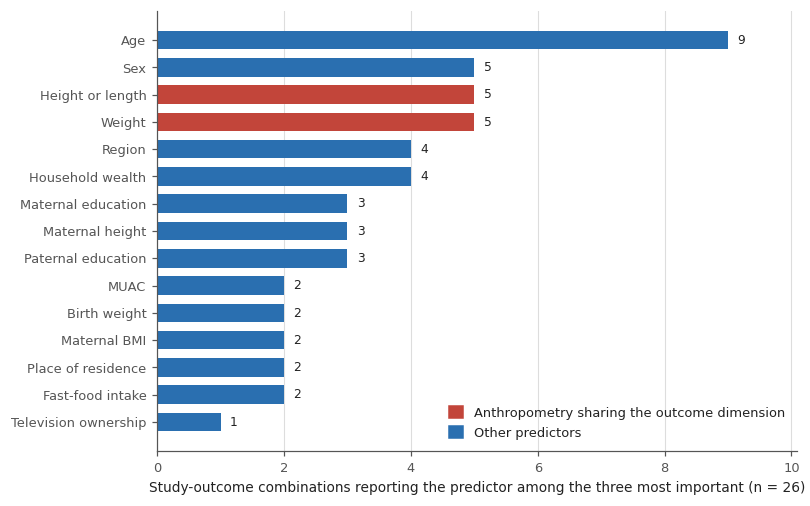

combinacoes com top-3 reportado: 26/39 | preditores canonicos: 37


In [61]:
# -- 10.3 Figure 4: preditores mais frequentes no top-3 --
# nomes canonicos: o texto livre dos artigos traz variantes da mesma variavel
CANONICO = [
    (r'weight[- ]for[- ](height|length)|\bwhz\b', 'Weight-for-height'),
    (r'weight[- ]for[- ]age|\bwaz\b', 'Weight-for-age'),
    (r'height[- ]for[- ]age|\bhaz\b', 'Height-for-age'),
    (r'birth\s*(weight|_weight)|weight at birth', 'Birth weight'),
    (r'birth\s*(length|height)', 'Birth length'),
    (r"(maternal|mother'?s?)\s*(bmi|body mass)", "Maternal BMI"),
    (r"(maternal|mother'?s?)\s*(height|stature)", "Maternal height"),
    (r"(maternal|mother'?s?|mother)\s*educ", 'Maternal education'),
    (r"(paternal|father'?s?|partner)\s*educ", 'Paternal education'),
    (r'wealth', 'Household wealth'),
    (r'\bregion\b|province|district', 'Region'),
    (r'child.*sex|^sex|gender', 'Sex'),
    (r'child.*age|^age|age in months', 'Age'),
    (r'child.*(length|height)|^height|^length|stature', 'Height or length'),
    (r'child.*weight|^weight|weight at ', 'Weight'),
    (r'\bbmi\b|body mass', 'Body mass index'),
    (r'muac|upper arm circumference', 'MUAC'),
    (r'antenatal', 'Antenatal care'),
    (r'place of delivery|delivery place', 'Place of delivery'),
    (r'breastfeed|breast feeding', 'Breastfeeding'),
    (r'consanguineous', 'Consanguineous marriage'),
    (r'television|\btv\b', 'Television ownership'),
    (r'fast food', 'Fast-food intake'),
    (r'toilet|sanitation|water source', 'Water and sanitation'),
    (r'residen|urban|rural', 'Place of residence'),
    (r'diarrh', 'Diarrhoea'),
    (r'vitamin|supplement', 'Micronutrient supplementation'),
    (r'household size|number of (children|household)', 'Household size'),
]


def canoniza(txt):
    t = str(txt).strip().lower()
    for padrao, nome in CANONICO:
        if re.search(padrao, t):
            return nome
    return t[:38].capitalize()


top = df_comb_eleg[['familia', '3 Most Important Features']].dropna()
top = top[top['3 Most Important Features'].str.upper() != 'NR']
feats = []
for fam, linha in zip(top['familia'], top['3 Most Important Features']):
    vistos = set()
    for f in str(linha).split(';'):
        f = f.strip()
        if not f:
            continue
        nome = canoniza(f)
        if nome in vistos:      # variantes da mesma variavel contam uma vez por combinacao
            continue
        vistos.add(nome)
        feats.append({'preditor': nome, 'antro_desfecho': bool(acha_termos(f, fam))})
fdf = pd.DataFrame(feats)
cont = (fdf.groupby('preditor')
        .agg(combinacoes=('preditor', 'count'), antro_desfecho=('antro_desfecho', 'max'))
        .sort_values('combinacoes'))
grava(cont.reset_index().sort_values('combinacoes', ascending=False), 'fig4_preditores.csv')
cont = cont.tail(15)

VERM, AZUL = '#C2453A', '#2A6FB0'
fig, ax = plt.subplots(figsize=(7.5, 5.2))
cores_barra = [VERM if a else AZUL for a in cont['antro_desfecho']]
barras = ax.barh(cont.index, cont['combinacoes'], color=cores_barra, height=0.68)
rotula_barras(ax, barras, cont['combinacoes'].values, dx=0.15, horizontal=True)
ax.set_xlabel(f'Study-outcome combinations reporting the predictor among the three most important '
              f'(n = {len(top)})')
ax.set_xlim(0, cont['combinacoes'].max() * 1.12)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_axisbelow(True)
ax.xaxis.grid(True)
mp = [plt.Rectangle((0, 0), 1, 1, color=VERM), plt.Rectangle((0, 0), 1, 1, color=AZUL)]
ax.legend(mp, ['Anthropometry sharing the outcome dimension', 'Other predictors'],
          loc='lower right', handlelength=1.1, handleheight=1.1)
fig_salva(fig, 'fig4_preditores')
plt.show()
print(f'combinacoes com top-3 reportado: {len(top)}/{n_comb_eleg} | preditores canonicos: {fdf["preditor"].nunique()}')

figura: resultados/figS2_desempenho_preditor_20260826.png/.pdf


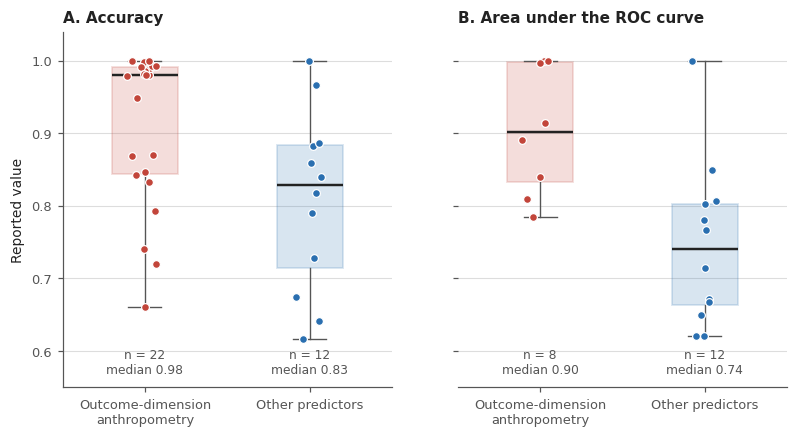

In [62]:
# -- 10.4 Figura S2: desempenho por tipo de preditor --
sub = df_comb[df_comb['elegivel']].copy()  # traz as flags da secao 09.1
sub['grupo'] = np.where(sub['antropometria_preditores'], 'Outcome-dimension\nanthropometry', 'Other predictors')
fig, eixos = plt.subplots(1, 2, figsize=(8.5, 4.2), sharey=True)
for eixo, metrica, titulo in zip(eixos, ['Accuracy', 'AUC'],
                                 ['A. Accuracy', 'B. Area under the ROC curve']):
    grupos = ['Outcome-dimension\nanthropometry', 'Other predictors']
    dados = [pd.to_numeric(sub.loc[sub['grupo'] == g, metrica], errors='coerce').dropna() for g in grupos]
    cx = eixo.boxplot(dados, widths=0.4, showfliers=False, patch_artist=True,
                      medianprops=dict(color=TINTA, linewidth=1.6),
                      whiskerprops=dict(color=TINTA2, linewidth=0.9),
                      capprops=dict(color=TINTA2, linewidth=0.9))
    for caixa_i, cor in zip(cx['boxes'], [VERM, AZUL]):
        caixa_i.set(facecolor=cor, alpha=0.18, edgecolor=cor, linewidth=1.2)
    rng2 = np.random.default_rng(20260826)
    for i_g, (d, cor) in enumerate(zip(dados, [VERM, AZUL]), start=1):
        eixo.scatter(rng2.normal(i_g, 0.045, len(d)), d, s=26, color=cor,
                     edgecolor='white', linewidth=0.8, zorder=3)
        eixo.text(i_g, 0.565, f'n = {len(d)}\nmedian {d.median():.2f}', ha='center', va='bottom',
                  fontsize=8, color=TINTA2)
    eixo.set_xticks([1, 2])
    eixo.set_xticklabels(grupos)
    eixo.set_title(titulo)
    eixo.set_ylim(0.55, 1.04)
    eixo.set_axisbelow(True)
    eixo.yaxis.grid(True)
eixos[1].spines['left'].set_visible(False)
eixos[0].set_ylabel('Reported value')
fig_salva(fig, 'figS2_desempenho_preditor')
plt.show()

## 11. PROBAST+AI por domínio

Demanda R2.6: o Revisor 2 leu o agregado ("96% alto risco") como baixa capacidade discriminatória do instrumento. A resposta é a decomposição por domínio (D1 a D4, desenvolvimento e avaliação), que mostra variação entre domínios. Denominador: 38 estudos. Os números conferem com os já publicados no Doc (97%, 87%/92%, aplicabilidade 61%/58%).

In [63]:
# -- 11.1 decomposicao por dominio --
DOM = {'Dev D1 Participants': 'D1 participantes', 'Dev D2 Predictors': 'D2 preditores',
       'Dev D3 Outcomes': 'D3 desfecho', 'Dev D4 Analyses': 'D4 analise',
       'Dev Overall': 'geral', 'Dev Applicability': 'aplicabilidade',
       'Eval D1 Participants': 'D1 participantes', 'Eval D2 Predictors': 'D2 preditores',
       'Eval D3 Outcomes': 'D3 desfecho', 'Eval D4 Apparent': 'D4 aparente',
       'Eval D4 Internal': 'D4 interna', 'Eval D4 External': 'D4 externa',
       'Eval Overall': 'geral', 'Eval Applicability': 'aplicabilidade'}
blocos = []
for col, rot in DOM.items():
    v = df_est[col].astype(str).str.strip().str.title().replace({'Nan': 'NA'})
    c = v.value_counts()
    blocos.append({'parte': 'desenvolvimento' if col.startswith('Dev') else 'avaliacao', 'dominio': rot,
                   **{k: int(c.get(k, 0)) for k in ['Low', 'High', 'Unclear', 'Na']}})
prob = pd.DataFrame(blocos)
for k in ['Low', 'High', 'Unclear']:
    prob[f'{k}_pct'] = (100 * prob[k] / 38).round(0).astype(int)
print(prob.to_string(index=False))
alto_dev = prob.loc[(prob['parte'] == 'desenvolvimento') & (prob['dominio'] == 'geral'), 'High'].iloc[0]
alto_ev = prob.loc[(prob['parte'] == 'avaliacao') & (prob['dominio'] == 'geral'), 'High'].iloc[0]
print(f'\ngeral: desenvolvimento {alto_dev}/38 High; avaliacao {alto_ev}/38 High | texto atual: 37/38 (97%) nas duas partes')
grava(prob, 'probast_dominios.csv')

          parte          dominio  Low  High  Unclear  Na  Low_pct  High_pct  Unclear_pct
desenvolvimento D1 participantes   14    13       10   0       37        34           26
desenvolvimento    D2 preditores   11     7       19   0       29        18           50
desenvolvimento      D3 desfecho   12    14       11   0       32        37           29
desenvolvimento       D4 analise    0    32        5   0        0        84           13
desenvolvimento            geral    0    36        1   0        0        95            3
desenvolvimento   aplicabilidade    4    22       11   0       11        58           29
      avaliacao D1 participantes   18    10        9   0       47        26           24
      avaliacao    D2 preditores   10     6       21   0       26        16           55
      avaliacao      D3 desfecho   16    18        3   0       42        47            8
      avaliacao      D4 aparente    3    10        3   0        8        26            8
      avaliacao      

## 12. Números para o manuscrito

Consolidação: uma linha por afirmação numérica do texto atual, com o valor antigo (base 43/47) e o valor novo (base v7). É o guia das substituições no Google Doc. Os valores das seções de leakage devem ser rerodados depois da conferência do template pela IVS.

In [64]:
# -- 12.1 consolidacao --
fmt = lambda v: ('' if pd.isna(v) else (f'{v:.2f}' if isinstance(v, float) else str(v)))
def med_iqr(serie):
    v = serie.dropna()
    return f'{v.median():.2f} (IQR {v.quantile(.25):.2f}-{v.quantile(.75):.2f}; n={len(v)})' if len(v) else 'NR'

L = []
def add(secao, afirmacao, antigo, novo):
    L.append({'secao': secao, 'afirmacao': afirmacao, 'valor_manuscrito_atual': antigo, 'valor_novo_v7': str(novo)})

add('Abstract/Results', 'estudos incluidos', '43 estudos / 47 combinacoes',
    f'{n_est_eleg} estudos / {n_comb_eleg} combinacoes elegiveis (38 estudos na base completa)')
for fam in ELEGIVEIS:
    n = int((df_comb_eleg['familia'] == fam).sum())
    add('Study characteristics', f'combinacoes de {fam}', f"{ANTIGO.get(fam, 0)}/47",
        f'{n}/{n_comb_eleg} ({100*n/n_comb_eleg:.0f}%)' if n else '0 (desfecho ausente na base de 38)')
add('Study characteristics', 'paises', '15 countries', f'{n_paises} paises')
add('Study characteristics', 'Indonesia', '23/47 (49%)',
    f'{ind_e}/38 estudos ({100*ind_e/38:.0f}%); {ind_c}/{n_comb_eleg} combinacoes ({100*ind_c/n_comb_eleg:.0f}%)')
add('Study characteristics', 'pico de publicacao', '26/47 (55%) em 2024',
    f'{int(anos.max())}/38 estudos ({100*anos.max()/38:.0f}%) em {pico}')
add('Study characteristics', 'amostra', '114 a 244.053 (mediana 6.677)',
    f'{int(ns.min())} a {int(ns.max())} (mediana {int(ns.median())}; {len(ns)}/38 com N)')
add('Study characteristics', 'Random Forest', '16/47 (34%)',
    f'{rf_est}/38 estudos ({100*rf_est/38:.0f}%); melhor modelo em {rf_melhor}/{n_comb_eleg} '
    f'combinacoes ({100*rf_melhor/n_comb_eleg:.0f}%); {rf}/241 linhas')
add('Study characteristics', 'deep learning', 'two studies', f'{len(dl_est)} estudos')
add('Predictive performance', 'AUC reportada', '20/47 (43%)', f'{auc_rep}/{n_comb_eleg} ({100*auc_rep/n_comb_eleg:.0f}%)')
for fam in ELEGIVEIS:
    g = df_comb_eleg[df_comb_eleg['familia'] == fam]
    if len(g):
        add('Predictive performance', f'AUC {fam}', 'ver texto', med_iqr(g['AUC']))
        add('Predictive performance', f'Accuracy {fam}', 'ver texto', med_iqr(g['Accuracy']))
add('Predictive performance', 'validacao externa', 'one study (2%)',
    f"{ext['ID'].nunique()} estudo(s): {list(ext['ID'].unique())}")
add('Class imbalance', 'prevalencia reportavel', '37/47 (79%)',
    f'{len(prev)}/{n_comb_eleg} ({100*len(prev)/n_comb_eleg:.0f}%)')
add('Class imbalance', 'prevalencia mediana', '17.0% (IQR 7.3-35.4)',
    f'{100*prev.median():.1f}% (IQR {100*prev.quantile(.25):.1f}-{100*prev.quantile(.75):.1f})')
add('Predictor variables', 'antropometria do desfecho (definicao atual)', '22/47 (47%)',
    f'{nA}/{len(el)} ({100*nA/len(el):.0f}%) [rerodar apos conferencia IVS]')
add('Predictor variables', 'contraste de accuracy', '0.97 vs 0.85',
    f"{dce.loc[dce['flag_antro'] == True, 'Accuracy'].median():.2f} vs {dce.loc[dce['flag_antro'] == False, 'Accuracy'].median():.2f} [rerodar apos conferencia IVS]")
add('Discussion', 'classificacao diagnostica vs predicao', 'nao classificado no texto',
    f'{int(diag.sum())}/{len(el)} combinacoes nowcasting ({100*diag.mean():.0f}%); prospectivas: {int(prosp.sum())}')
add('Risk of bias', 'PROBAST geral', '37/38 (97%) High nas duas partes',
    f'dev {alto_dev}/38 High; eval {alto_ev}/38 High')
if os.path.exists(AUDITORIA):
    a_ = pd.read_csv(AUDITORIA, sep=';', encoding='utf-8-sig')
    d_ = pd.read_csv(DIVERGENCIAS, sep=';', encoding='utf-8-sig')
    sev = d_['severidade'].value_counts()
    add('Methods/Limitations', 'auditoria da extracao', 'nao reportado no manuscrito',
        f"{len(a_)}/38 estudos reauditados contra o PDF (24/08); {sev.get('alta', 0)} divergencias altas, "
        f"{sev.get('media', 0)} medias, {sev.get('baixa', 0)} baixas; nenhum valor de desempenho em linha errada")
    add('Predictor variables', 'vazamento genuino', '22/47 (47%) descritos como data leakage',
        'nenhum dos 3 modelos prospectivos apos auditoria: AA_31 e AA_50 usam antropometria anterior ao '
        'desfecho, com horizonte temporal; o restante e tautologia diagnostica em modelo transversal')
    add('Predictive performance', 'comparabilidade das metricas', 'nao ressalvado no manuscrito',
        'precisao/recall/F1 sao macro-media ou media ponderada, e nao metrica da classe positiva, '
        'em parte dos estudos (ver auditoria_v7_temas.csv) — nao devem ser agrupados sem ressalva')
numeros = pd.DataFrame(L)
print(numeros.to_string(index=False))
grava(numeros, 'numeros_manuscrito.csv')

                 secao                                     afirmacao                  valor_manuscrito_atual                                                                                                                                                                              valor_novo_v7
      Abstract/Results                             estudos incluidos             43 estudos / 47 combinacoes                                                                                                                        37 estudos / 39 combinacoes elegiveis (38 estudos na base completa)
 Study characteristics                       combinacoes de stunting                                   32/47                                                                                                                                                                                30/39 (77%)
 Study characteristics                        combinacoes de obesity                                    9/47    

## 13. Auditoria da extração contra os PDFs (24/08)

Cada um dos 38 estudos foi reauditado por um leitor independente que abriu só o seu PDF e conferiu, campo a campo, o que a v7 afirma: identificação, desfechos, preditores e horizonte temporal, algoritmos, validação, as seis métricas de desempenho linha a linha, eventos e calibração. Regras da auditoria: valor de abstract não vale como fonte, o que o artigo não reporta é NR e o que o auditor não localiza é NAO_VERIFICAVEL, e toda divergência precisa de página e tabela.

Esta seção lê o resultado consolidado. Ela mede duas coisas diferentes: a fidelidade da transcrição (a planilha reproduz o artigo?) e a coerência do que foi extraído (o conjunto faz sentido com o desenho do estudo?).

In [65]:
# -- 13.1 vereditos por bloco --
if not os.path.exists(AUDITORIA):
    print('auditoria ainda nao consolidada; rode audit_v7/consolida.py antes desta secao')
else:
    aud = pd.read_csv(AUDITORIA, sep=';', encoding='utf-8-sig')
    div = pd.read_csv(DIVERGENCIAS, sep=';', encoding='utf-8-sig')
    BLOCOS = ['A_identificacao', 'B_desfecho', 'C_preditores', 'D_modelo',
              'E_validacao', 'F_desempenho', 'G_eventos', 'H_calibracao']
    print(f'estudos auditados: {len(aud)}/38')
    vb = pd.DataFrame({b: aud[b].value_counts() for b in BLOCOS}).T.fillna(0).astype(int)
    for c in ['OK', 'PARCIAL', 'DIVERGE', 'NAO_VERIFICAVEL']:
        if c not in vb.columns:
            vb[c] = 0
    vb = vb[['OK', 'PARCIAL', 'DIVERGE', 'NAO_VERIFICAVEL']]
    print()
    print(vb.to_string())
    grava(vb.reset_index().rename(columns={'index': 'bloco'}), 'auditoria_v7_vereditos_por_bloco.csv')

estudos auditados: 38/38

                 OK  PARCIAL  DIVERGE  NAO_VERIFICAVEL
A_identificacao  14       24        0                0
B_desfecho       37        1        0                0
C_preditores     27       11        0                0
D_modelo         34        4        0                0
E_validacao      29        9        0                0
F_desempenho     25       13        0                0
G_eventos        33        5        0                0
H_calibracao     38        0        0                0
gravado: resultados/auditoria_v7_vereditos_por_bloco.csv (8 linhas x 5 colunas)


In [66]:
# -- 13.2 divergencias por severidade e bloco --
if os.path.exists(DIVERGENCIAS):
    print(div['severidade'].value_counts().rename('divergencias').to_string())
    print()
    print(pd.crosstab(div['bloco'], div['severidade']).to_string())
    altas = div[div['severidade'] == 'alta']
    print(f'\n== {len(altas)} divergencias de severidade alta ==')
    for _, r in altas.iterrows():
        print(f"{r['ID']} | {r['campo']}: planilha '{str(r['valor_na_planilha'])[:28]}' vs artigo "
              f"'{str(r['valor_no_artigo'])[:28]}' ({r['evidencia']})")
    lim = aud[aud['n_divergencias'] == 0]['ID'].tolist()
    print(f'\nestudos sem nenhuma divergencia: {len(lim)} {lim}')

severidade
baixa    76
media    33
alta      2

severidade              alta  baixa  media
bloco                                     
A_identificacao            0     35      5
B_desfecho                 0      1      0
C_preditores               0     14      4
D_modelo                   0      6      0
E_validacao                0      6      4
F_desempenho               1      7     15
G_eventos                  0      4      2
I_obs                      0      2      0
derivado_pelo_notebook     1      1      3

== 2 divergencias de severidade alta ==
AA_36 | AUC_raw / AUC (campo igual em todas as linhas 126-131): planilha 'NR' vs artigo 'Severely Stunting AUC = 0.58' (Fig. 4 'ROC Curve', p.6 — legenda do grafico traz os tres valores numericos de AUC. O texto da secao G (p.6) diz apenas 'AUC values are nearly 0.5', mas os numeros exatos estao na figura. A propria secao II.D (p.3) declara: 'The AUC ... was acknowledged as the primary performance metric'.)
AA_44 | classificacao_final

In [67]:
# -- 13.3 finalidade: auditor x proposta automatica --
if os.path.exists(AUDITORIA):
    conc = aud['auditor_concorda'].astype(str).str.lower()
    print(f"auditor concorda com o rotulo de finalidade: {int((conc == 'true').sum())}/{len(aud)}")
    disc = aud[conc == 'false']
    for _, r in disc.iterrows():
        print(f"  {r['ID']}: proposto '{r['finalidade_proposta']}' -> auditor '{r['finalidade_correta']}'")
    print()
    antro = aud['antropometria_do_desfecho_entre_preditores'].astype(str).str.lower()
    print(f"auditores confirmam antropometria do proprio desfecho entre os preditores em "
          f"{int((antro == 'true').sum())}/{len(aud)} estudos")

auditor concorda com o rotulo de finalidade: 36/38
  AA_44: proposto 'predicao prospectiva' -> auditor 'classificacao diagnostica (nowcasting) - preditores concorrentes ao desfecho, com historico imediato anterior; NAO ha horizonte temporal declarado'
  AA_46: proposto 'misto (conferir)' -> auditor 'classificacao diagnostica (nowcasting)'

auditores confirmam antropometria do proprio desfecho entre os preditores em 23/38 estudos


In [68]:
# -- 13.4 leitura de coerencia por estudo --
if os.path.exists(AUDITORIA):
    cols_ver = ['ID', 'artigo', 'desenho', 'n_divergencias', 'n_alta',
                'finalidade_correta', 'antropometria_do_desfecho_entre_preditores', 'coerencia_geral']
    print(aud[cols_ver].head(38).to_string(index=False, max_colwidth=70))

   ID                                                                 artigo                                                                desenho  n_divergencias  n_alta                                                     finalidade_correta  antropometria_do_desfecho_entre_preditores                                                        coerencia_geral
AA_36 Advanced Machine Learning Techniques for Stunting Classification Us...              transversal (inquerito nacional de saude, uma unica onda)               6       1                                 classificacao diagnostica (nowcasting)                                       False O nucleo quantitativo da extracao esta correto: as 24 celulas de Ac...
AA_44 Conceptualizing bias in EHR data: performance disparities by demogr... caso-controle pareado 1:1 retrospectivo, derivado de coorte retrosp...               6       1 classificacao diagnostica (nowcasting) - preditores concorrentes ao...                                       Fal

## 14. Busca atualizada em Embase e Web of Science (R2.4)

O Revisor 2 aponta a ausência de Embase e Web of Science. A busca foi repetida nas duas bases em 09/07/2026 com a estratégia original (`base_dados/embase_revision_20260709.ris` e `wos_revision_20260709.ris`).

Três perguntas são respondidas aqui: quantos registros as duas bases trouxeram, quantos deles não haviam sido recuperados pelas quatro bases originais, e quantos dos estudos já incluídos as duas bases conseguem recuperar. A última é o teste de sensibilidade: se as bases novas não recuperam nem os estudos que já estão na revisão, a cobertura delas para esta literatura é menor que a das bases originais.

In [69]:
# -- 14.1 leitura dos RIS e contagem por base --
import unicodedata

def norm_txt(t):
    t = unicodedata.normalize('NFKD', str(t)).encode('ascii', 'ignore').decode()
    return re.sub(r'\s+', ' ', re.sub(r'[^a-z0-9 ]', ' ', t.lower())).strip()

def le_ris(caminho):
    regs, cur = [], {}
    for ln in open(caminho, encoding='utf-8', errors='ignore'):
        m = re.match(r'^([A-Z][A-Z0-9])  - (.*)$', ln.rstrip('\n'))
        if not m:
            continue
        tag, val = m.groups()
        if tag == 'TY':
            if cur:
                regs.append(cur)
            cur = {}
        cur.setdefault(tag, []).append(val)
    if cur:
        regs.append(cur)
    saida = []
    for r in regs:
        ti = (r.get('TI') or r.get('T1') or [''])[0]
        saida.append({'titulo': ti, 'doi': (r.get('DO') or [''])[0].lower().strip(),
                      'ano': (r.get('Y1') or r.get('PY') or [''])[0][:4], 'tnorm': norm_txt(ti)})
    return saida

emb = le_ris(f'{BASE_DADOS}/embase_revision_20260709.ris')
wos = le_ris(f'{BASE_DADOS}/wos_revision_20260709.ris')
print(f'Embase: {len(emb)} registros | Web of Science: {len(wos)} registros | total {len(emb) + len(wos)}')

orig_chaves = set()
for arq in ['sistematica_ml_07_23_2025_bvs.ris', 'sistematica_ml_07_23_2025_scopus.ris',
            'sistematica_ml_07_23_2025_ieee_pt1.ris', 'sistematica_ml_07_23_2025_ieee_pt2.ris']:
    for r in le_ris(f'{BASE_DADOS}/{arq}'):
        orig_chaves.update({k for k in (r['tnorm'], r['doi']) if k})
pm = pd.read_csv(f'{BASE_DADOS}/sistematica_ml_07_23_2025_pubmed.csv')
col_ti = [c for c in pm.columns if 'title' in c.lower()][0]
orig_chaves.update({norm_txt(t) for t in pm[col_ti] if isinstance(t, str)})
if 'DOI' in pm.columns:
    orig_chaves.update({str(d).lower().strip() for d in pm['DOI'] if isinstance(d, str) and d.strip()})
print(f'chaves de titulo/DOI da busca original: {len(orig_chaves)}')

Embase: 240 registros | Web of Science: 360 registros | total 600
chaves de titulo/DOI da busca original: 7437


In [70]:
# -- 14.2 deduplicacao e registros ineditos --
unicos = {}
for nome, base in [('Embase', emb), ('Web of Science', wos)]:
    for r in base:
        ch = r['doi'] or r['tnorm']
        if not ch:
            continue
        unicos.setdefault(ch, {'reg': r, 'bases': set()})['bases'].add(nome)
dup_entre_bases = len(emb) + len(wos) - len(unicos)
ineditos = {c: v for c, v in unicos.items()
            if v['reg']['tnorm'] not in orig_chaves and not (v['reg']['doi'] and v['reg']['doi'] in orig_chaves)}
ja_recuperados = len(unicos) - len(ineditos)
print(f'unicos apos deduplicacao entre as duas bases: {len(unicos)} (duplicatas entre bases: {dup_entre_bases})')
print(f'ja recuperados pela busca original: {ja_recuperados} | ineditos: {len(ineditos)}')

novos_df = pd.DataFrame([{'titulo': v['reg']['titulo'], 'ano': v['reg']['ano'], 'doi': v['reg']['doi'],
                          'bases': ' + '.join(sorted(v['bases'])), 'triagem_IVS': '', 'motivo_IVS': ''}
                         for v in ineditos.values()]).sort_values(['ano', 'titulo'], ascending=[False, True])
grava(novos_df, 'busca_atualizada_novos.csv')

unicos apos deduplicacao entre as duas bases: 434 (duplicatas entre bases: 166)
ja recuperados pela busca original: 236 | ineditos: 198
gravado: resultados/busca_atualizada_novos.csv (198 linhas x 6 colunas)


In [71]:
# -- 14.3 teste de sensibilidade: as bases novas recuperam os estudos ja incluidos? --
dois_inc = {str(d).lower().strip() for d in df_est['DOI'] if isinstance(d, str) and d.strip() and d.upper() != 'NR'}
rec = {}
for nome, base in [('Embase', emb), ('Web of Science', wos)]:
    rec[nome] = {r['doi'] for r in base if r['doi'] and r['doi'] in dois_inc}
uniao = rec['Embase'] | rec['Web of Science']
print(f'estudos incluidos com DOI: {len(dois_inc)}/{len(df_est)}')
for nome, hit in rec.items():
    print(f'  {nome}: recupera {len(hit)}/{len(dois_inc)} ({100 * len(hit) / len(dois_inc):.0f}%)')
print(f'  uniao das duas: {len(uniao)}/{len(dois_inc)} ({100 * len(uniao) / len(dois_inc):.0f}%)')
print(f'  quatro bases originais: {len(dois_inc)}/{len(dois_inc)} (100%), por construcao do conjunto')

busca = pd.DataFrame([
    {'base': 'Scopus', 'busca': 'original (05/08/2025)', 'registros': 285, 'fonte_da_contagem': 'documento Estrategia de Busca'},
    {'base': 'PubMed', 'busca': 'original (05/08/2025)', 'registros': 127, 'fonte_da_contagem': 'documento Estrategia de Busca'},
    {'base': 'IEEE Xplore', 'busca': 'original (05/08/2025)', 'registros': 129, 'fonte_da_contagem': 'documento Estrategia de Busca'},
    {'base': 'BVS/LILACS', 'busca': 'original (05/08/2025)', 'registros': 53, 'fonte_da_contagem': 'documento Estrategia de Busca'},
    {'base': 'Embase', 'busca': 'atualizada (09/07/2026)', 'registros': len(emb), 'fonte_da_contagem': 'RIS exportado'},
    {'base': 'Web of Science', 'busca': 'atualizada (09/07/2026)', 'registros': len(wos), 'fonte_da_contagem': 'RIS exportado'},
])
busca['estudos_incluidos_recuperados'] = [None, None, None, None, len(rec['Embase']), len(rec['Web of Science'])]
grava(busca, 'busca_atualizada.csv')

estudos incluidos com DOI: 37/37
  Embase: recupera 17/37 (46%)
  Web of Science: recupera 18/37 (49%)
  uniao das duas: 19/37 (51%)
  quatro bases originais: 37/37 (100%), por construcao do conjunto
gravado: resultados/busca_atualizada.csv (6 linhas x 5 colunas)


gravado: resultados/prisma_contagens.csv (14 linhas x 4 colunas)
figura: resultados/fig1_prisma_20260826.png/.pdf


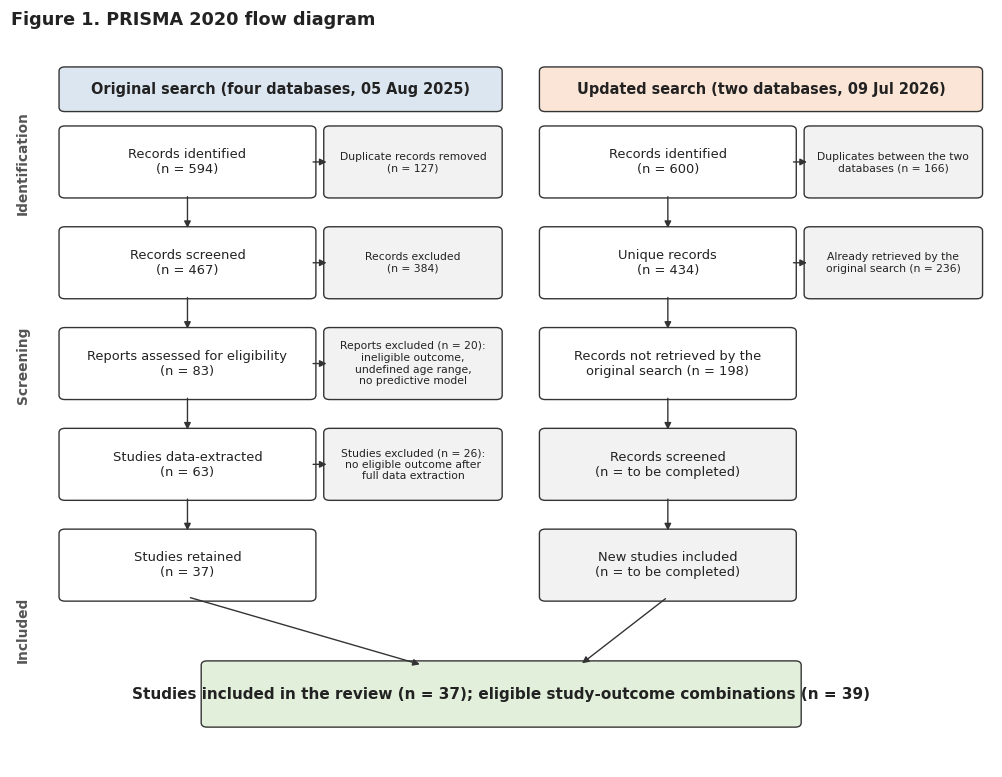

In [72]:
# -- 14.4 fluxograma PRISMA 2020 --
import matplotlib.patches as mpatches

PRISMA = [
    ('original', 'identificados', 594, 'Scopus 285, PubMed 127, IEEE Xplore 129, BVS 53 (documento Estrategia de Busca, 05/08/2025)'),
    ('original', 'duplicatas removidas', 127, 'log 2.4; o manuscrito submetido registra 235, divergencia nao resolvida'),
    ('original', 'triados', 467, '594 - 127'),
    ('original', 'excluidos na triagem', 384, 'documento Estrategia de Busca'),
    ('original', 'texto completo avaliado', 83, 'documento Estrategia de Busca'),
    ('original', 'excluidos no texto completo', 20, '83 avaliados - 63 extraidos; desfecho ineligivel, faixa etaria indefinida, ausencia de modelagem preditiva'),
    ('original', 'extraidos', 63, 'extracao v3'),
    ('original', 'excluidos apos extracao', 26, 'extracao v4: sem desfecho elegivel isolado, desfecho fora do escopo, coorte duplicada, desfecho composto sem dimensao antropometrica isolavel'),
    ('atualizada', 'identificados', len(emb) + len(wos), f'Embase {len(emb)}, Web of Science {len(wos)} (09/07/2026)'),
    ('atualizada', 'duplicatas entre as duas bases', dup_entre_bases, 'DOI ou titulo normalizado'),
    ('atualizada', 'ja recuperados pela busca original', ja_recuperados, 'DOI ou titulo normalizado contra as exportacoes das quatro bases'),
    ('atualizada', 'ineditos a triar', len(ineditos), 'lista em busca_atualizada_novos.csv'),
    ('final', 'estudos incluidos na revisao', len(df_est), 'base de extracao v7'),
    ('final', 'estudos com desfecho elegivel', df_comb_eleg['ID'].nunique(), 'stunting, overweight, obesity'),
]
grava(pd.DataFrame(PRISMA, columns=['coluna', 'caixa', 'n', 'fonte']), 'prisma_contagens.csv')
val = {(c, k): n for c, k, n, _ in PRISMA}

def caixa(ax, x, y, w, h, txt, cor='white', tam=8.5, negrito=False):
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.006',
                                         linewidth=0.9, edgecolor='#333333', facecolor=cor))
    ax.text(x + w / 2, y + h / 2, txt, ha='center', va='center', fontsize=tam,
            fontweight='bold' if negrito else 'normal')

def seta(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='-|>', color='#333333', linewidth=0.9))

fig, ax = plt.subplots(figsize=(11.5, 8.5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
LX, RX, LW, EW, H = 0.055, 0.545, 0.25, 0.17, 0.088
caixa(ax, LX, 0.915, LW + EW + 0.02, 0.05, 'Original search (four databases, 05 Aug 2025)', '#DCE6F1', 9.5, True)
caixa(ax, RX, 0.915, LW + EW + 0.02, 0.05, 'Updated search (two databases, 09 Jul 2026)', '#FBE5D6', 9.5, True)
ys = [0.795, 0.655, 0.515, 0.375, 0.235]
esq = [f"Records identified\n(n = {val[('original', 'identificados')]})",
       f"Records screened\n(n = {val[('original', 'triados')]})",
       f"Reports assessed for eligibility\n(n = {val[('original', 'texto completo avaliado')]})",
       f"Studies data-extracted\n(n = {val[('original', 'extraidos')]})",
       f"Studies retained\n(n = {len(df_est)})"]
esq_lat = [f"Duplicate records removed\n(n = {val[('original', 'duplicatas removidas')]})",
           f"Records excluded\n(n = {val[('original', 'excluidos na triagem')]})",
           f"Reports excluded (n = {val[('original', 'excluidos no texto completo')]}):\nineligible outcome,\nundefined age range,\nno predictive model",
           f"Studies excluded (n = {val[('original', 'excluidos apos extracao')]}):\nno eligible outcome after\nfull data extraction",
           None]
dir_ = [f"Records identified\n(n = {val[('atualizada', 'identificados')]})",
        f"Unique records\n(n = {val[('atualizada', 'identificados')] - val[('atualizada', 'duplicatas entre as duas bases')]})",
        f"Records not retrieved by the\noriginal search (n = {val[('atualizada', 'ineditos a triar')]})",
        "Records screened\n(n = to be completed)",
        "New studies included\n(n = to be completed)"]
dir_lat = [f"Duplicates between the two\ndatabases (n = {val[('atualizada', 'duplicatas entre as duas bases')]})",
           f"Already retrieved by the\noriginal search (n = {val[('atualizada', 'ja recuperados pela busca original')]})",
           None, None, None]
for i, y in enumerate(ys):
    caixa(ax, LX, y, LW, H, esq[i])
    if esq_lat[i]:
        caixa(ax, LX + LW + 0.02, y, EW, H, esq_lat[i], '#F2F2F2', 7)
        seta(ax, LX + LW, y + H / 2, LX + LW + 0.02, y + H / 2)
    caixa(ax, RX, y, LW, H, dir_[i], '#F2F2F2' if i >= 3 else 'white')
    if dir_lat[i]:
        caixa(ax, RX + LW + 0.02, y, EW, H, dir_lat[i], '#F2F2F2', 7)
        seta(ax, RX + LW, y + H / 2, RX + LW + 0.02, y + H / 2)
    if i:
        seta(ax, LX + LW / 2, ys[i - 1], LX + LW / 2, y + H)
        seta(ax, RX + LW / 2, ys[i - 1], RX + LW / 2, y + H)
caixa(ax, 0.20, 0.06, 0.60, 0.08,
      f"Studies included in the review (n = {len(df_est)}); "
      f"eligible study-outcome combinations (n = {len(df_comb_eleg)})", '#E2EFDA', 10, True)
seta(ax, LX + LW / 2, ys[-1], 0.42, 0.14)
seta(ax, RX + LW / 2, ys[-1], 0.58, 0.14)
for rot, y0, y1 in [('Identification', 0.795, 0.88), ('Screening', 0.375, 0.74), ('Included', 0.06, 0.32)]:
    ax.text(0.012, (y0 + y1) / 2, rot, rotation=90, ha='center', va='center', fontsize=9,
            fontweight='bold', color='#555555')
ax.set_title('Figure 1. PRISMA 2020 flow diagram', fontsize=11.5, fontweight='bold', loc='left', pad=14)
fig_salva(fig, 'fig1_prisma')
plt.show()

## 15. Certeza da evidência (R2.2)

O Revisor 2 aponta que o GRADE está mencionado sem domínios nem resultado. Não existe GRADE consolidado para revisão de modelos preditivos, então a avaliação é declarada como adaptada: os cinco domínios são julgados por desfecho, o PROBAST+AI entra como insumo do domínio de risco de viés, e a certeza final é reportada por desfecho.

Os julgamentos são derivados de quantidades calculadas nas seções anteriores, sem entrada manual. Regra de rebaixamento: risco de viés em dois níveis quando 80% ou mais dos estudos do desfecho são de risco alto, por ser risco muito sério; inconsistência quando a amplitude de AUC atinge 0,20; indireção quando metade ou mais das combinações é classificação diagnóstica; imprecisão quando menos de cinco combinações reportam AUC.

In [73]:
# -- 15.1 tabela de certeza por desfecho --
linhas_grade = []
comb_fin = df_comb[df_comb['elegivel']].copy()  # traz rotulo_proposto da secao 09.1
comb_fin['pais'] = comb_fin['Country/Region'].map(pais_norm)
for fam in ELEGIVEIS:
    g = comb_fin[comb_fin['familia'] == fam]
    if g.empty:
        continue
    ids = g['ID'].unique()
    auc = pd.to_numeric(g['AUC'], errors='coerce').dropna()
    alto_rv = int((df_est.loc[df_est['ID'].isin(ids), 'Dev Overall'].astype(str).str.strip().str.lower() == 'high').sum())
    nowc = int(g['rotulo_proposto'].astype(str).str.startswith('classificacao').sum())
    ind_pct = 100 * (g['pais'] == 'Indonesia').mean()
    rebaixa, niveis = [], 0
    if alto_rv / len(ids) >= 0.8:
        rebaixa.append('risco de vies (muito serio, 2 niveis)')
        niveis += 2
    if len(auc) > 1 and (auc.max() - auc.min()) >= 0.20:
        rebaixa.append('inconsistencia')
        niveis += 1
    if nowc / len(g) >= 0.5:
        rebaixa.append('indirecao')
        niveis += 1
    if len(auc) < 5:
        rebaixa.append('imprecisao')
        niveis += 1
    certeza = {0: 'alta', 1: 'moderada', 2: 'baixa'}.get(niveis, 'muito baixa')
    linhas_grade.append({
        'desfecho': fam, 'estudos': len(ids), 'combinacoes': len(g),
        'risco_de_vies': f'alto em {alto_rv}/{len(ids)} estudos (PROBAST+AI, desenvolvimento)',
        'inconsistencia': (f'AUC de {auc.min():.2f} a {auc.max():.2f} em {len(auc)} combinacoes'
                           if len(auc) else 'AUC nao reportada em nenhuma combinacao'),
        'indirecao': f'{nowc}/{len(g)} sao classificacao diagnostica; {ind_pct:.0f}% das combinacoes na Indonesia',
        'imprecisao': f'AUC reportada em {len(auc)}/{len(g)} combinacoes; N mediano {int(g["N (sample)"].median())}',
        'vies_de_publicacao': 'nao avaliavel formalmente; predominio de literatura de congresso indexada no IEEE Xplore',
        'dominios_rebaixados': '; '.join(rebaixa),
        'niveis_rebaixados': niveis,
        'certeza': certeza,
    })
grade = pd.DataFrame(linhas_grade)
print(grade[['desfecho', 'estudos', 'combinacoes', 'dominios_rebaixados', 'niveis_rebaixados', 'certeza']].to_string(index=False))
grava(grade, 'grade_certainty.csv')

                      desfecho  estudos  combinacoes                                              dominios_rebaixados  niveis_rebaixados     certeza
                      stunting       30           30 risco de vies (muito serio, 2 niveis); inconsistencia; indirecao                  4 muito baixa
                       obesity        6            6                            risco de vies (muito serio, 2 niveis)                  2       baixa
                    overweight        2            2     risco de vies (muito serio, 2 niveis); indirecao; imprecisao                  4 muito baixa
overweight/obesity (combinado)        1            1     risco de vies (muito serio, 2 niveis); indirecao; imprecisao                  4 muito baixa
gravado: resultados/grade_certainty.csv (4 linhas x 11 colunas)


## 16. Figuras finais para o manuscrito

Copia para `jhpn_revisions/figures/` o conjunto que substitui as figuras do artigo. A Figura 3 (PROBAST+AI, 17/08) já está lá e não é regerada aqui.

In [74]:
# -- 16.1 copia das figuras finais --
import shutil

FINAIS = ['fig1_prisma', 'fig2_distribuicao', 'fig4_preditores',
          'figS1_auc_desfecho', 'figS2_desempenho_preditor']
os.makedirs(FIGURAS, exist_ok=True)
for nome in FINAIS:
    for ext in ('png', 'pdf'):
        arq = f'{OUT_DIR}/{nome}_{DATA}.{ext}'
        if os.path.exists(arq):
            shutil.copy2(arq, f'{FIGURAS}/{nome}_{DATA}.{ext}')
            print(f'figures/{nome}_{DATA}.{ext}')
        else:
            print(f'AUSENTE: {nome}_{DATA}.{ext}')
print('mantida sem alteracao: fig3_probastai_20260817.png/.pdf')

figures/fig1_prisma_20260826.png
figures/fig1_prisma_20260826.pdf
figures/fig2_distribuicao_20260826.png
figures/fig2_distribuicao_20260826.pdf
figures/fig4_preditores_20260826.png
figures/fig4_preditores_20260826.pdf
figures/figS1_auc_desfecho_20260826.png
figures/figS1_auc_desfecho_20260826.pdf
figures/figS2_desempenho_preditor_20260826.png
figures/figS2_desempenho_preditor_20260826.pdf
mantida sem alteracao: fig3_probastai_20260817.png/.pdf


## 17. Tabelas do manuscrito

Exporta as tabelas na forma em que entram no artigo, em inglês. Table 1, Table 2 e Table 3 vão no corpo; as demais entram como material adicional. O arquivo `.docx` formatado é montado por `scratchpad/docx_mr/build_tabelas.py` a partir destes CSVs.

In [75]:
# -- 17.1 Table 1: caracteristicas e desempenho por combinacao --
def fmt_num(v, casas=2):
    return 'NR' if pd.isna(v) else f'{v:.{casas}f}'

t1 = df_comb_eleg.copy()
t1['Outcome_EN'] = t1['familia'].map(ROTULO_EN)
t1['Country'] = t1['pais'].replace({'USA': 'United States', 'Asia (dataset multinacional)': 'Multinational (Asia)'})
t1['Sample'] = t1['N (sample)'].map(lambda v: 'NR' if pd.isna(v) else f'{int(v):,}')
t1['AUC_f'] = t1['AUC'].map(fmt_num)
t1['Accuracy_f'] = t1['Accuracy'].map(fmt_num)
t1['RoB'] = t1['Dev Overall'].astype(str).str.strip().str.capitalize()
finalidade = df_comb.set_index(['ID', 'familia'])['rotulo_proposto']  # uma por combinacao, nao por estudo
t1['Purpose'] = [finalidade.get((i, f), '') for i, f in zip(t1['ID'], t1['familia'])]
t1['Purpose'] = t1['Purpose'].map({'classificacao diagnostica (nowcasting)': 'Diagnostic',
                                   'predicao prospectiva': 'Prospective'}).fillna('Undetermined')
tabela1 = t1[['First Author', 'Year', 'Country', 'Sample', 'Age (months)', 'Outcome_EN',
              'Algorithm', 'AUC_f', 'Accuracy_f', 'Purpose', 'RoB']].copy()
tabela1.columns = ['First author', 'Year', 'Country', 'N', 'Age (months)', 'Outcome',
                   'Best model', 'AUC', 'Accuracy', 'Model purpose', 'Risk of bias']
tabela1 = tabela1.sort_values(['Year', 'First author', 'Outcome'])
grava(tabela1, 'table1_estudos.csv')
print(tabela1.head(6).to_string(index=False))

gravado: resultados/table1_estudos.csv (39 linhas x 11 colunas)
          First author  Year       Country       N                                                          Age (months)  Outcome                               Best model  AUC Accuracy Model purpose Risk of bias
                  Pang  2021 United States  27,203 0-84 (predictors from 0-24 months; outcome assessed >24 to 84 months)  Obesity                            XGBoost (XGB) 0.81     0.66   Prospective         High
Rahman, S. M. Jubaidur  2021    Bangladesh   7,079                                                                  0-59 Stunting                       Random Forest (RF) 0.71     0.88    Diagnostic         High
                  Zare  2021 United States 244,053                                                                60-120  Obesity                Artificial neural network 0.79     0.87   Prospective         High
         Chilyabanyama  2022        Zambia   6,799                                      

In [76]:
# -- 17.2 Table 2: desempenho e heterogeneidade por desfecho --
t2 = pd.read_csv(f'{OUT_DIR}/table2_nova.csv', sep=';', encoding='utf-8-sig')
het = pd.read_csv(f'{OUT_DIR}/heterogeneidade.csv', sep=';', encoding='utf-8-sig')
t2 = t2.merge(het[['familia', 'N_min', 'N_max', 'prev_min', 'prev_max', 'paises']],
              left_on='desfecho', right_on='familia', how='left')
tabela2 = pd.DataFrame({
    'Outcome': t2['desfecho'].map(ROTULO_EN),
    'Combinations': t2['combinacoes'],
    'AUC, n': t2['AUC_N'],
    'AUC, median (IQR)': [f'{m:.2f} ({i})' if pd.notna(m) else 'NR'
                          for m, i in zip(t2['AUC_mediana'], t2['AUC_IQR'])],
    'Accuracy, n': t2['Accuracy_N'],
    'Accuracy, median (IQR)': [f'{m:.2f} ({i})' if pd.notna(m) else 'NR'
                               for m, i in zip(t2['Accuracy_mediana'], t2['Accuracy_IQR'])],
    'Sample size, range': [f'{int(a):,} to {int(b):,}' if pd.notna(a) else 'NR'
                           for a, b in zip(t2['N_min'], t2['N_max'])],
    'Outcome prevalence, range (%)': [f'{a:.1f} to {b:.1f}' if pd.notna(a) else 'NR'
                                      for a, b in zip(t2['prev_min'], t2['prev_max'])],
    'Countries': t2['paises'],
})
grava(tabela2, 'table2_desempenho.csv')
print(tabela2.to_string(index=False))

gravado: resultados/table2_desempenho.csv (4 linhas x 9 colunas)
           Outcome  Combinations  AUC, n AUC, median (IQR)  Accuracy, n Accuracy, median (IQR) Sample size, range Outcome prevalence, range (%)  Countries
          Stunting            30      12  0.86 (0.75-1.00)           30       0.88 (0.80-0.99)     114 to 121,000                   0.7 to 51.6         11
           Obesity             6       5  0.79 (0.78-0.81)            3       0.87 (0.77-0.92)   5,983 to 244,053                  15.5 to 50.0          3
        Overweight             2       2  0.71 (0.67-0.76)            1       0.89 (0.89-0.89)    5,983 to 18,503                  17.6 to 17.6          2
Overweight/obesity             1       1  0.62 (0.62-0.62)            0                     NR     6,801 to 6,801                            NR          1


In [77]:
# -- 17.3 Table 3: certeza da evidencia --
g = pd.read_csv(f'{OUT_DIR}/grade_certainty.csv', sep=';', encoding='utf-8-sig')
CERTEZA_EN = {'muito baixa': 'Very low', 'baixa': 'Low', 'moderada': 'Moderate', 'alta': 'High'}
def serio(campo, marcado):
    return 'Very serious' if 'muito serio' in str(campo) else ('Serious' if marcado else 'Not serious')
tabela3 = pd.DataFrame({
    'Outcome': g['desfecho'].map(ROTULO_EN),
    'Studies': g['estudos'],
    'Risk of bias': ['Very serious' if 'risco de vies' in d else 'Not serious' for d in g['dominios_rebaixados']],
    'Inconsistency': ['Serious' if 'inconsistencia' in d else 'Not serious' for d in g['dominios_rebaixados']],
    'Indirectness': ['Serious' if 'indirecao' in d else 'Not serious' for d in g['dominios_rebaixados']],
    'Imprecision': ['Serious' if 'imprecisao' in d else 'Not serious' for d in g['dominios_rebaixados']],
    'Publication bias': 'Not assessed',
    'Certainty': g['certeza'].map(CERTEZA_EN),
})
grava(tabela3, 'table3_grade.csv')
print(tabela3.to_string(index=False))

gravado: resultados/table3_grade.csv (4 linhas x 8 colunas)
           Outcome  Studies Risk of bias Inconsistency Indirectness Imprecision Publication bias Certainty
          Stunting       30 Very serious       Serious      Serious Not serious     Not assessed  Very low
           Obesity        6 Very serious   Not serious  Not serious Not serious     Not assessed       Low
        Overweight        2 Very serious   Not serious      Serious     Serious     Not assessed  Very low
Overweight/obesity        1 Very serious   Not serious      Serious     Serious     Not assessed  Very low


In [78]:
# -- 17.4 tabelas do material adicional --
# S2: desfechos extraidos fora do escopo declarado (R2.5)
s2 = pd.read_csv(f'{OUT_DIR}/auditoria_desfechos_R2_5.csv', sep=';', encoding='utf-8-sig')
s2 = s2.rename(columns={'ID': 'Study ID', 'First Author': 'First author', 'familia': 'Outcome extracted'})
grava(s2, 'tableS2_desfechos_fora_escopo.csv')

# S3: PROBAST+AI por dominio
s3 = pd.read_csv(f'{OUT_DIR}/probast_dominios.csv', sep=';', encoding='utf-8-sig')
s3['parte'] = s3['parte'].map({'desenvolvimento': 'Model development', 'avaliacao': 'Model evaluation'})
s3 = s3.rename(columns={'parte': 'Part', 'dominio': 'Domain', 'Low_pct': 'Low (%)',
                        'High_pct': 'High (%)', 'Unclear_pct': 'Unclear (%)'})
grava(s3[['Part', 'Domain', 'Low', 'High', 'Unclear', 'Low (%)', 'High (%)', 'Unclear (%)']],
      'tableS3_probast_dominios.csv')

# S4: contribuicao por base
s4 = pd.read_csv(f'{OUT_DIR}/busca_atualizada.csv', sep=';', encoding='utf-8-sig')
s4 = s4.rename(columns={'base': 'Database', 'busca': 'Search', 'registros': 'Records retrieved',
                        'fonte_da_contagem': 'Source of the count',
                        'estudos_incluidos_recuperados': 'Included studies retrieved (of 38)'})
grava(s4, 'tableS4_bases.csv')

# S5: verificacao da extracao contra os PDFs
s5 = pd.read_csv(f'{OUT_DIR}/auditoria_v7_por_estudo.csv', sep=';', encoding='utf-8-sig')
s5 = s5[['ID', 'ano', 'n_divergencias', 'n_alta', 'finalidade_correta',
         'antropometria_do_desfecho_entre_preditores']]
s5.columns = ['Study ID', 'Year', 'Divergences', 'Of which affecting the synthesis',
              'Model purpose after verification', 'Outcome-dimension anthropometry among predictors']
grava(s5.sort_values('Study ID'), 'tableS5_verificacao.csv')
print('tabelas do material adicional gravadas')

gravado: resultados/tableS2_desfechos_fora_escopo.csv (14 linhas x 6 colunas)
gravado: resultados/tableS3_probast_dominios.csv (14 linhas x 8 colunas)
gravado: resultados/tableS4_bases.csv (6 linhas x 5 colunas)
gravado: resultados/tableS5_verificacao.csv (38 linhas x 6 colunas)
tabelas do material adicional gravadas


## 18. Próximo passo

1. IVS confere `resultados/classificacao_finalidade_TEMPLATE.csv` (colunas `rotulo_IVS` e `leakage_IVS`) e a `auditoria_desfechos_R2_5.csv`; com o template marcado, rerodar as seções 10 e 12.
2. IVS decide, em `auditoria_v7_divergencias.csv` (coluna `aceito_IVS`), quais correções entram numa v8 da extração. A v7 não é alterada por este notebook.
3. Decidir o texto para os desfechos fora do escopo (auditoria R2.5) e para a combinação overweight/obesity combinada.
4. Levar `numeros_manuscrito.csv` para as substituições no Google Doc MARKED (junto com as figuras novas em `resultados/`).
5. GRADE (T2.2) e PRISMA/re-busca (T1.1, T1.7, R2.4) ficam para notebooks próprios, depois das decisões metodológicas.